# Разведочный анализ данных и выявление аномалий водопотребления по показаниям приборов учёта


Работа движется от проверки исходных данных к расчёту расхода, поиску отдельных признаков и сопоставлению с событиями. Каждая глава объясняет, зачем выполняется расчёт, как читать его результат и какие выводы он позволяет сделать.

## Исходные данные

| Файл | Что содержит | Роль в анализе |
|---|---|---|
| `pokazaniya.csv` | Прибор, дата, накопительное показание и количество пакетов за сутки | Основной источник для расчёта расхода |
| `pribory.csv` | Станция, тип, модель и месяц выпуска | Сравнение групп приборов |
| `sobytiya.csv` | Прибор, дата и событие: магнит, сброс или Холл | Сопоставление событий с изменениями расхода |

Разделитель CSV — `;`, кодировка — UTF-8. Идентификаторы приборов и станций условные. Показания измеряются в кубометрах: **1 м³ = 1 000 литров**. Большое накопительное показание само по себе не является аномалией; анализируется его изменение.

## Запуск и воспроизводимость

Три CSV должны находиться в рабочей папке запуска либо путь к ним должен быть задан в `DATA_DIR`. В PyCharm рабочая папка может отличаться от папки notebook. Для выполнения нужны Python, pandas, matplotlib и IPython; запуск notebook требует настроенного Jupyter kernel.

Ячейки выполняются последовательно сверху вниз. Для полного пересчёта используется **Restart Kernel → Run All**. Повторный запуск отдельных ячеек объединения таблиц или добавления строк сводки может изменить состояние переменных. Сохранённые выводы и графики относятся к выполнению, уже находившемуся в исходном notebook; при изменении файлов или порогов результаты необходимо пересчитать.

## Основные определения

| Термин | Значение |
|---|---|
| Накопительное показание | Объём, зарегистрированный счётчиком к дате наблюдения |
| Расход за интервал | Разница двух последовательных показаний одного прибора |
| Суточный расход | Эта разница, если даты отличаются ровно на один календарный день |
| Медиана | Центральное значение упорядоченного набора; менее чувствительно к отдельным большим скачкам, чем среднее |
| Серия | Последовательность календарных дней, удовлетворяющих одному условию, без пропусков |
| Магнитный эпизод | Последовательные даты с зарегистрированным событием «магнит» одного прибора |
| Кандидат на проверку | Прибор с заданным признаком; неисправность или причина ещё не подтверждены |

## Правила интерпретации

- Пропуск данных не считается нулевым потреблением. Расход через несколько дней не распределяется по дням без дополнительных оснований.
- Отрицательные разницы сохраняются для расследования. Они показывают уменьшение зарегистрированного счётчика, а не отрицательное использование воды.
- Пороги служат прозрачными правилами отбора. Они не заменяют паспортные ограничения приборов и сведения об объектах.
- Положительный расход каждый день не доказывает непрерывную утечку внутри суток. Поступление пакетов не доказывает исправность измерительного механизма.
- Совпадение аномалии с событием по времени не устанавливает причинную связь.

## 1. Загрузка и устройство данных

Первые таблицы показывают, что означает строка каждого файла и какие поля доступны. Данные пока не очищаются; идентификатор читается как текст, поскольку он не участвует в арифметике.

Задаётся путь к CSV и подключаются инструменты работы с таблицами. `Path(".")` означает текущую рабочую папку процесса, а не гарантированно папку notebook.

In [161]:
from pathlib import Path

import pandas as pd
from IPython.display import display

DATA_DIR = Path(".")

Загружается основной файл. `head()` показывает первые строки для проверки названий и смысла полей; это пример записей, а не описание всего набора.

In [162]:
readings = pd.read_csv(
    DATA_DIR / "pokazaniya.csv",
    sep=";",
    encoding="utf-8",
    dtype={"anon_id": "string"},
)

display(readings.head())

,anon_id,data,pokazanie,paketov_za_sutki
0,6478032,2025-10-01,18.690,1
1,6478032,2025-10-02,18.774,1
2,6478032,2025-10-03,18.855,1
3,6478032,2025-10-04,18.895,1
4,6478032,2025-10-05,18.933,1


In [163]:
meters = pd.read_csv(
    DATA_DIR / "pribory.csv",
    sep=";",
    encoding="utf-8",
    dtype={"anon_id": "string"},
)

display(meters.head())

,anon_id,bs,tip,model,mesyac_vypuska
0,6478032,BS-01,aqua2_stm,АКВА L110 D15 C E,2022-10
1,4743501,BS-01,aqua2_stm,АКВА L110 D15 B E,2025-10
2,4382302,BS-01,aqua2_nvt_wa_stm,АКВА L110 D15 B E,2025-11
3,9325487,BS-01,aqua2_nvt_wa_stm,АКВА L110 D15 C E,2023-09
4,6754005,BS-01,aqua2_nvt_wa_stm,АКВА L110 D15 C E,2025-12


In [164]:
events = pd.read_csv(
    DATA_DIR / "sobytiya.csv",
    sep=";",
    encoding="utf-8",
    dtype={"anon_id": "string"},
)

display(events.head())

,anon_id,data,sobytie
0,6478032,2026-09-29,магнит
1,6478032,2026-09-29,магнит
2,6478032,2026-09-28,магнит
3,6478032,2026-09-28,магнит
4,6478032,2026-09-28,магнит


**Размер таблиц.** Количество строк отражает объём записей, количество уникальных ID — число представленных приборов. Совпадение количества приборов ещё не доказывает совпадение самих идентификаторов.

In [165]:
overview = pd.DataFrame({
    "Таблица": ["Показания", "Приборы", "События"],
    "Количество строк": [len(readings), len(meters), len(events)],
    "Уникальных приборов": [
        readings["anon_id"].nunique(),
        meters["anon_id"].nunique(),
        events["anon_id"].nunique(),
    ],
})

display(overview)

,Таблица,Количество строк,Уникальных приборов
0,Показания,693443,3000
1,Приборы,3000,3000
2,События,34009,689


**Результат загрузки.** В показаниях 693 443 строки для 3 000 приборов, в справочнике 3 000 приборов, в событиях 34 009 строк для 689 приборов. Это размеры источников, а не количество аномалий.

## 2. Качество данных и связь таблиц

Проверяются типы, пустые значения, повторяющиеся строки и наличие приборов в справочнике. Особенно важна уникальность пары «прибор — дата»: без неё разница показаний может быть неоднозначной.

**Типы столбцов.** Проверяется, какие поля прочитаны как числа, даты или текст. Текстовую дату необходимо преобразовать перед вычислением расстояния между наблюдениями.

In [166]:
print("ПОКАЗАНИЯ")
print(readings.dtypes)

print("\nПРИБОРЫ")
print(meters.dtypes)

print("\nСОБЫТИЯ")
print(events.dtypes)

ПОКАЗАНИЯ
anon_id              string
data                    str
pokazanie           float64
paketov_za_sutki      int64
dtype: object

ПРИБОРЫ
anon_id           string
bs                   str
tip                  str
model                str
mesyac_vypuska       str
dtype: object

СОБЫТИЯ
anon_id    string
data          str
sobytie       str
dtype: object


**Преобразование дат.** Указанный формат делает разбор дат однозначным; `errors="raise"` не позволяет незаметно пропустить ошибку. Первое число месяца выпуска — техническое представление месяца, а не точный день изготовления.

In [167]:
readings["data"] = pd.to_datetime(
    readings["data"],
    format="%Y-%m-%d",
    errors="raise",
)

events["data"] = pd.to_datetime(
    events["data"],
    format="%Y-%m-%d",
    errors="raise",
)

meters["mesyac_vypuska"] = pd.to_datetime(
    meters["mesyac_vypuska"],
    format="%Y-%m",
    errors="raise",
)

**Контроль преобразования.** В выводе ожидаются типы даты для всех трёх временных полей. Это проверка формата, но не полноты календаря.

In [168]:
print("Дата показания:", readings["data"].dtype)
print("Дата события:", events["data"].dtype)
print("Месяц выпуска:", meters["mesyac_vypuska"].dtype)

Дата показания: datetime64[us]
Дата события: datetime64[us]
Месяц выпуска: datetime64[us]


**Пустые ячейки.** Считаются отсутствующие значения каждого поля. Отсутствующие даты наблюдений будут проверены отдельно: заполненная таблица может содержать календарные разрывы.

In [169]:
print("ПОКАЗАНИЯ")
display(readings.isna().sum().rename("Пустых значений"))

print("ПРИБОРЫ")
display(meters.isna().sum().rename("Пустых значений"))

print("СОБЫТИЯ")
display(events.isna().sum().rename("Пустых значений"))

ПОКАЗАНИЯ


anon_id             0
data                0
pokazanie           0
paketov_za_sutki    0
Name: Пустых значений, dtype: int64

ПРИБОРЫ


anon_id            0
bs                 0
tip                0
model             19
mesyac_vypuska     0
Name: Пустых значений, dtype: int64

СОБЫТИЯ


anon_id    0
data       0
sobytie    0
Name: Пустых значений, dtype: int64

**Приборы без модели.** Показываются строки с неизвестной моделью. Такие приборы не исключаются из расчёта расхода; модель не заполняется предположениями.

In [170]:
meters_without_model = meters[
    meters["model"].isna()
]

display(meters_without_model.head(10))

,anon_id,bs,tip,model,mesyac_vypuska
1223,8576071,BS-05,AQUA2,NaN,2019-12-01
1312,3240435,BS-05,AQUA2,NaN,2020-02-01
1325,9602898,BS-05,AQUA2,NaN,2019-12-01
1354,9562096,BS-05,AQUA2,NaN,2020-02-01
1375,2539133,BS-05,AQUA2,NaN,2019-12-01
1388,5997780,BS-05,AQUA2,NaN,2019-12-01
1410,7606795,BS-05,AQUA2,NaN,2020-01-01
1411,4750133,BS-05,AQUA2,NaN,2020-02-01
1457,7344301,BS-05,AQUA2,NaN,2020-02-01
1478,8973572,BS-05,AQUA2,NaN,2019-12-01


**Полные повторы.** Считаются строки, полностью повторяющие уже встреченные. Повторы событий не означают столько же независимых срабатываний.

In [171]:
print(
    "Показания:",
    readings.duplicated().sum(),
)

print(
    "Приборы:",
    meters.duplicated().sum(),
)

print(
    "События:",
    events.duplicated().sum(),
)

Показания: 0
Приборы: 0
События: 23223


**Однозначность показаний за день.** Проверяется пара «прибор — дата». Разные показания на одну дату потребовали бы отдельного правила выбора; в исходных данных таких повторов нет.

In [172]:
same_meter_and_date = readings.duplicated(
    subset=["anon_id", "data"],
    keep=False,
)

print(
    "Строк с повторяющейся парой «прибор — дата»:",
    same_meter_and_date.sum(),
)

Строк с повторяющейся парой «прибор — дата»: 0


**Событие как дневной признак.** Создаётся отдельная таблица уникальных сочетаний «прибор — дата — тип события». Исходная таблица сохраняется. Запись означает наличие события за день, а не ровно одно срабатывание.

In [173]:
events_daily = events.drop_duplicates(
    subset=["anon_id", "data", "sobytie"]
).copy()

print("Строк в исходной таблице:", len(events))
print("Уникальных событий за день:", len(events_daily))

Строк в исходной таблице: 34009
Уникальных событий за день: 10786


**Совпадение идентификаторов.** Проверяется, все ли приборы из показаний и событий есть в справочнике и есть ли показания у приборов справочника. Ноль в выводе означает отсутствие ID в соответствующей разности наборов.

In [174]:
reading_ids = set(readings["anon_id"])
meter_ids = set(meters["anon_id"])
event_ids = set(events["anon_id"])

print(
    "Приборов из показаний нет в справочнике:",
    len(reading_ids - meter_ids),
)

print(
    "Приборов из событий нет в справочнике:",
    len(event_ids - meter_ids),
)

print(
    "Приборов справочника нет в показаниях:",
    len(meter_ids - reading_ids),
)

Приборов из показаний нет в справочнике: 0
Приборов из событий нет в справочнике: 0
Приборов справочника нет в показаниях: 0


**Результат проверки качества.** Пустых значений в показаниях и событиях нет; у 19 приборов неизвестна модель. Пара «прибор — дата» в показаниях уникальна. В событиях 23 223 повторные строки; после сведения к дневному признаку остаются 10 786 записей. Идентификаторы показаний и событий присутствуют в справочнике.

## 3. Даты наблюдений и пропуски

Определяются границы набора и расстояния между записями. Эта глава устанавливает, для каких интервалов можно получить суточный расход. График числа приборов описывает доступность наблюдений, а не потребление воды.

**Общие границы периода.** Минимальная и максимальная даты относятся ко всему набору. У конкретного прибора период наблюдений может быть короче.

In [175]:
periods = pd.DataFrame({
    "Таблица": ["Показания", "События"],
    "Первая дата": [
        readings["data"].min(),
        events["data"].min(),
    ],
    "Последняя дата": [
        readings["data"].max(),
        events["data"].max(),
    ],
})

display(periods)

,Таблица,Первая дата,Последняя дата
0,Показания,2025-10-01,2026-10-01
1,События,2025-10-01,2026-10-01


**Приборы по датам.** Для каждой даты считается число приборов с записью. Полный календарь добавляет отсутствующие даты с нулевым количеством наблюдаемых приборов; расход при этом не заполняется.

In [176]:
meters_per_day = readings.groupby("data")["anon_id"].nunique()

calendar = pd.date_range(
    start=readings["data"].min(),
    end=readings["data"].max(),
    freq="D",
)

meters_per_day = meters_per_day.reindex(
    calendar,
    fill_value=0,
)

**График доступности данных.** По горизонтали — дата, по вертикали — количество приборов с показанием. Провалы характеризуют отсутствие записей, но сами по себе не доказывают отказ связи или прекращение использования воды.

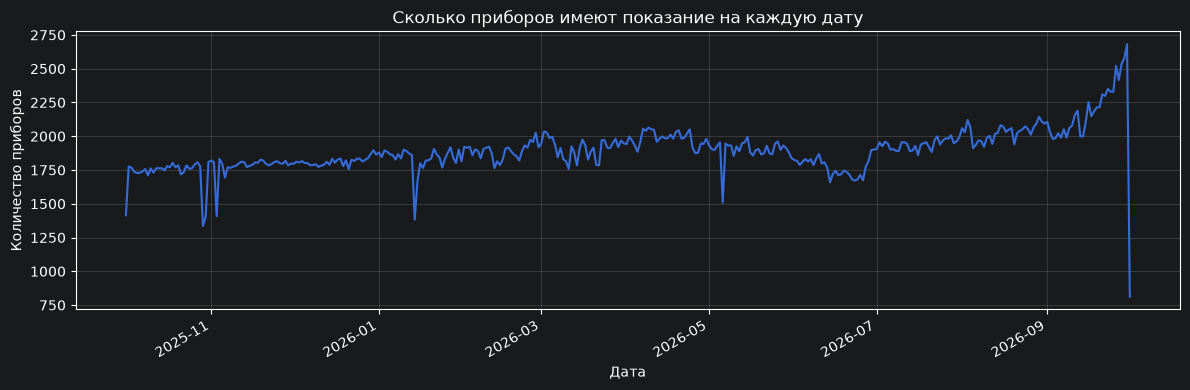

In [177]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(meters_per_day.index, meters_per_day.values)

ax.set_title("Сколько приборов имеют показание на каждую дату")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество приборов")

ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Порядок наблюдений.** Записи сортируются по прибору и дате. `shift(1)` добавляет предыдущую дату внутри того же прибора; первая запись остаётся без предыдущей.

In [178]:
readings_sorted = readings.sort_values(
    ["anon_id", "data"]
).copy()

readings_sorted["previous_date"] = (
    readings_sorted
    .groupby("anon_id")["data"]
    .shift(1)
)

**Длина интервала.** Расстояние между датами выражается в днях. Значение 2 означает один пропущенный промежуточный день; значение 1 позволяет вычислить суточную разницу.

In [179]:
readings_sorted["days_between"] = (
    readings_sorted["data"]
    - readings_sorted["previous_date"]
).dt.days

display(
    readings_sorted[
        ["anon_id", "previous_date", "data", "days_between"]
    ].head(10)
)

,anon_id,previous_date,data,days_between
440708,1001589,NaT,2025-10-01,NaN
440709,1001589,2025-10-01,2025-10-02,1.0
440710,1001589,2025-10-02,2025-10-03,1.0
440711,1001589,2025-10-03,2025-10-04,1.0
440712,1001589,2025-10-04,2025-10-05,1.0
440713,1001589,2025-10-05,2025-10-06,1.0
440714,1001589,2025-10-06,2025-10-07,1.0
440715,1001589,2025-10-07,2025-10-08,1.0
440716,1001589,2025-10-08,2025-10-09,1.0
440717,1001589,2025-10-09,2025-10-10,1.0


**Пригодность для суточного расчёта.** Отдельно считаются первые записи, соседние дни и более длинные интервалы. Эти группы объясняют, почему число суточных расходов меньше числа показаний.

In [180]:
interval_summary = pd.DataFrame({
    "Вид записи": [
        "Первая запись прибора",
        "Интервал ровно один день",
        "Интервал больше одного дня",
    ],
    "Количество": [
        readings_sorted["days_between"].isna().sum(),
        readings_sorted["days_between"].eq(1).sum(),
        readings_sorted["days_between"].gt(1).sum(),
    ],
})

display(interval_summary)

,Вид записи,Количество
0,Первая запись прибора,3000
1,Интервал ровно один день,616414
2,Интервал больше одного дня,74029


**Примеры разрывов.** Показываются конкретные интервалы с пропусками. Разница показаний через такой интервал относится ко всему промежутку, а не только к последней дате.

In [181]:
gaps = readings_sorted[
    readings_sorted["days_between"] > 1
]

display(
    gaps[
        ["anon_id", "previous_date", "data", "days_between"]
    ].head(10)
)

,anon_id,previous_date,data,days_between
440743,1001589,2025-11-04,2025-11-06,2.0
440782,1001589,2025-12-14,2025-12-16,2.0
440786,1001589,2025-12-19,2025-12-21,2.0
440788,1001589,2025-12-22,2025-12-24,2.0
440806,1001589,2026-01-10,2026-01-12,2.0
440808,1001589,2026-01-13,2026-01-15,2.0
440812,1001589,2026-01-18,2026-01-20,2.0
440813,1001589,2026-01-20,2026-01-22,2.0
440821,1001589,2026-01-29,2026-01-31,2.0
440828,1001589,2026-02-06,2026-02-08,2.0


**Результат проверки дат.** Период набора — 01.10.2025–01.10.2026. Есть 616 414 интервалов ровно в сутки и 74 029 более длинных интервалов, плюс 3 000 первых записей. Только первая группа позволяет получить непосредственно наблюдаемый суточный расход.

## 4. Расчёт суточного расхода

После сортировки внутри каждого прибора из текущего показания вычитается предыдущее. Суточное значение сохраняется только для соседних календарных дней. Отрицательные и неизвестные значения остаются различимыми.

**Числовые поля.** Подтверждается числовой формат показаний и пакетов. Некорректная строка остановит преобразование вместо незаметной подстановки пустого значения.

In [182]:
readings_sorted["pokazanie"] = pd.to_numeric(
    readings_sorted["pokazanie"],
    errors="raise",
)

readings_sorted["paketov_za_sutki"] = pd.to_numeric(
    readings_sorted["paketov_za_sutki"],
    errors="raise",
)

**Допустимость значений.** Проверяются отрицательные накопительные показания и недопустимые количества пакетов. Отсутствие этих нарушений ещё не гарантирует достоверность самих показаний.

In [183]:
print(
    "Отрицательных накопительных показаний:",
    readings_sorted["pokazanie"].lt(0).sum(),
)

print(
    "Отрицательных значений количества пакетов:",
    readings_sorted["paketov_za_sutki"].lt(0).sum(),
)

print(
    "Нецелых значений количества пакетов:",
    readings_sorted["paketov_za_sutki"].mod(1).ne(0).sum(),
)

Отрицательных накопительных показаний: 0
Отрицательных значений количества пакетов: 0
Нецелых значений количества пакетов: 0


**Предыдущее показание.** Добавляется предыдущий накопительный счётчик того же прибора. Показания разных приборов не вычитаются друг из друга.

In [184]:
readings_sorted["previous_reading"] = (
    readings_sorted
    .groupby("anon_id")["pokazanie"]
    .shift(1)
)

**Две величины расхода.** `interval_consumption` — разница за наблюдаемый интервал; `daily_consumption` — та же разница только при соседних датах. Неизвестный суточный расход обозначается `NaN`, а не нулём.

In [185]:
readings_sorted["interval_consumption"] = (
    readings_sorted["pokazanie"]
    - readings_sorted["previous_reading"]
)

readings_sorted["daily_consumption"] = (
    readings_sorted["interval_consumption"]
    .where(readings_sorted["days_between"].eq(1))
)

**Проверка на отдельных строках.** Текущие и предыдущие значения расположены рядом, чтобы проверить вычитание вручную. Отрицательная разница остаётся в таблице, поскольку является объектом исследования.

In [186]:
columns_to_check = [
    "anon_id",
    "previous_date",
    "data",
    "days_between",
    "previous_reading",
    "pokazanie",
    "interval_consumption",
    "daily_consumption",
]

display(readings_sorted[columns_to_check].head(10))

,anon_id,previous_date,data,days_between,previous_reading,pokazanie,interval_consumption,daily_consumption
440708,1001589,NaT,2025-10-01,NaN,NaN,280.760,NaN,NaN
440709,1001589,2025-10-01,2025-10-02,1.0,280.760,280.840,0.080,0.080
440710,1001589,2025-10-02,2025-10-03,1.0,280.840,280.864,0.024,0.024
440711,1001589,2025-10-03,2025-10-04,1.0,280.864,280.910,0.046,0.046
440712,1001589,2025-10-04,2025-10-05,1.0,280.910,281.130,0.220,0.220
440713,1001589,2025-10-05,2025-10-06,1.0,281.130,281.180,0.050,0.050
440714,1001589,2025-10-06,2025-10-07,1.0,281.180,281.340,0.160,0.160
440715,1001589,2025-10-07,2025-10-08,1.0,281.340,281.360,0.020,0.020
440716,1001589,2025-10-08,2025-10-09,1.0,281.360,281.410,0.050,0.050
440717,1001589,2025-10-09,2025-10-10,1.0,281.410,281.447,0.037,0.037


**Знак расхода.** Доступные суточные разницы делятся на отрицательные, нулевые и положительные. `EPS=1e-9` — технический допуск числового сравнения, а не паспортная точность или порог аномалии.

In [187]:
daily = readings_sorted[
    readings_sorted["daily_consumption"].notna()
].copy()

consumption = daily["daily_consumption"]

EPS = 1e-9

consumption_summary = pd.DataFrame({
    "Расход": ["Отрицательный", "Нулевой", "Положительный"],
    "Количество дней": [
        consumption.lt(-EPS).sum(),
        consumption.abs().le(EPS).sum(),
        consumption.gt(EPS).sum(),
    ],
})

display(consumption_summary)

,Расход,Количество дней
0,Отрицательный,190
1,Нулевой,216005
2,Положительный,400219


**Основной масштаб потребления.** Квантили показывают границы, ниже которых лежит заданная доля неотрицательных расходов, включая нули. Это характеристика записей набора, а не универсальная норма для объекта.

In [188]:
nonnegative_consumption = consumption[
    consumption.ge(-EPS)
].clip(lower=0)

quantiles = nonnegative_consumption.quantile(
    [0.50, 0.90, 0.99]
)

quantiles.index = [
    "50% дней имеют расход не выше",
    "90% дней имеют расход не выше",
    "99% дней имеют расход не выше",
]

display(quantiles.rename("м³/сутки").to_frame())

,м³/сутки
50% дней имеют расход не выше,0.036000
90% дней имеют расход не выше,0.317000
99% дней имеют расход не выше,1.162968


**Распределение расхода.** Гистограмма показывает диапазон до 99-го процентиля. Верхний 1% скрыт только при отображении; все значения остаются в расчётах. Высокий первый столбец включает нули и небольшие расходы.

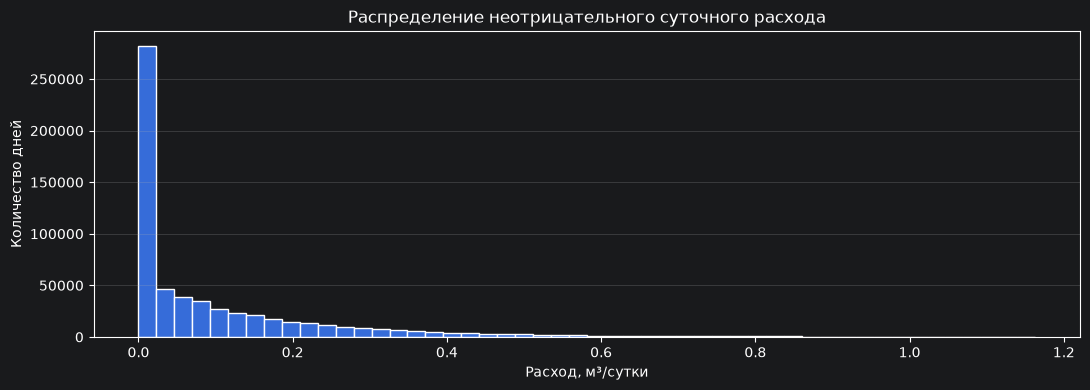

In [189]:
plot_limit = nonnegative_consumption.quantile(0.99)

values_for_plot = nonnegative_consumption[
    nonnegative_consumption.le(plot_limit)
]

fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(values_for_plot, bins=50, edgecolor="white")

ax.set_title("Распределение неотрицательного суточного расхода")
ax.set_xlabel("Расход, м³/сутки")
ax.set_ylabel("Количество дней")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Результат расчёта.** Из 616 414 суточных разниц 190 отрицательны, 216 005 нулевые и 400 219 положительны. Среди неотрицательных расходов медиана — около 0,036 м³, 90-й процентиль — 0,317 м³, 99-й — 1,163 м³. Частота нулей показывает, что один нулевой день сам по себе не является неисправностью.

## 5. Уменьшение накопительного показания

Рассматриваются отрицательные суточные разницы и уменьшения через более длинные интервалы. Возможные причины включают сброс, замену, переполнение и ошибки обработки данных. Причина не определяется только по знаку разницы.

**Отрицательные сутки.** Считаются отрицательные суточные разницы и уникальные приборы. Критерий — расход меньше `−EPS` при интервале ровно один день.

In [190]:
negative_daily = daily[
    daily["daily_consumption"].lt(-EPS)
].copy()

print("Отрицательных суточных разниц:", len(negative_daily))
print("Приборов:", negative_daily["anon_id"].nunique())

Отрицательных суточных разниц: 190
Приборов: 79


**Все уменьшения счётчика.** Дополнительно учитываются отрицательные разницы через пропуски. Их нельзя назвать суточным расходом, но само уменьшение зарегистрированного показания известно.

In [191]:
negative_intervals = readings_sorted[
    readings_sorted["interval_consumption"].lt(-EPS)
].copy()

print("Всего уменьшений:", len(negative_intervals))
print("Приборов:", negative_intervals["anon_id"].nunique())

print(
    "Уменьшений через интервал больше суток:",
    negative_intervals["days_between"].gt(1).sum(),
)

Всего уменьшений: 269
Приборов: 102
Уменьшений через интервал больше суток: 79


**Ранжирование падений.** Приборы сравниваются по самому большому суточному падению и числу отрицательных дней. Наиболее отрицательное значение определяет порядок строк.

In [192]:
negative_by_meter = (
    negative_daily
    .groupby("anon_id")
    .agg(
        negative_days=("daily_consumption", "size"),
        largest_drop=("daily_consumption", "min"),
    )
    .sort_values("largest_drop")
    .reset_index()
)

display(negative_by_meter.head(10))

,anon_id,negative_days,largest_drop
0,2491162,2,-3.006487e+06
1,8908023,1,-2.684367e+06
2,2159987,1,-2.949060e+03
3,7891133,2,-2.293389e+03
4,8190741,8,-1.311426e+03
5,1423304,5,-1.310846e+03
6,7293232,7,-1.310800e+03
7,5704914,4,-1.310783e+03
8,2030325,13,-1.310765e+03
9,5905051,3,-1.310752e+03


**Выбор подробного примера.** Автоматически выбирается крупнейшее суточное падение и окно ±3 дня. Такой пример показывает форму сильной аномалии, но не является типичным для всей выборки.

In [193]:
worst_row = negative_daily.loc[
    negative_daily["daily_consumption"].idxmin()
]

example_id = worst_row["anon_id"]
drop_date = worst_row["data"]

window_start = drop_date - pd.Timedelta(days=3)
window_end = drop_date + pd.Timedelta(days=3)

**История вокруг падения.** Показания, расход и пакеты позволяют проверить последовательность событий. Большой положительный скачок перед падением меняет интерпретацию отрицательного дня.

In [194]:
example = readings_sorted[
    readings_sorted["anon_id"].eq(example_id)
    & readings_sorted["data"].between(window_start, window_end)
].copy()

display(
    example[
        [
            "data",
            "pokazanie",
            "days_between",
            "daily_consumption",
            "paketov_za_sutki",
        ]
    ]
)

,data,pokazanie,days_between,daily_consumption,paketov_za_sutki
442975,2026-07-07,1.214893e+03,1.0,3.243349e+02,25
442976,2026-07-08,1.363849e+03,1.0,1.489564e+02,25
442977,2026-07-09,3.006868e+06,1.0,3.005504e+06,27
442978,2026-07-10,3.808143e+02,1.0,-3.006487e+06,25
442979,2026-07-11,3.808831e+02,1.0,6.879121e-02,25
442980,2026-07-12,5.992663e+02,1.0,2.183833e+02,26
442981,2026-07-13,7.085100e+02,1.0,1.092437e+02,25


**График накопительного счётчика.** Красная линия отмечает дату падения. Огромный пик сжимает остальные значения по вертикали; малые различия лучше читать в таблице.

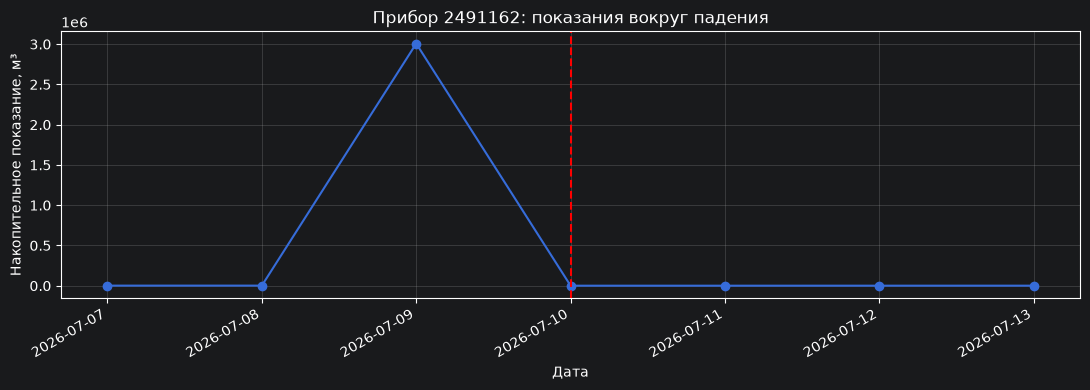

In [195]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(example["data"], example["pokazanie"], marker="o")
ax.axvline(drop_date, color="red", linestyle="--")

ax.set_title(f"Прибор {example_id}: показания вокруг падения")
ax.set_xlabel("Дата")
ax.set_ylabel("Накопительное показание, м³")

ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**События выбранного прибора.** Ищутся любые зарегистрированные события в том же временном окне. Пустая таблица означает отсутствие записей в выгрузке, а не доказанное отсутствие воздействия или обслуживания.

In [196]:
example_events = events_daily[
    events_daily["anon_id"].eq(example_id)
    & events_daily["data"].between(window_start, window_end)
]

display(example_events)

,anon_id,data,sobytie


**Результат по уменьшениям.** Найдено 269 отрицательных интервалов у 102 приборов; 190 из них — суточные, у 79 приборов. Пример `2491162` показывает огромный скачок перед падением. Следовательно, отрицательный день следует проверять вместе с предыдущими показаниями и возможными сбросами.

## 6. Абсолютные и относительные всплески

Абсолютный критерий оценивает величину расхода. Относительный сравнивает его с индивидуальной медианой прибора. Эти выборки дополняют друг друга и могут пересекаться.

**Крупнейшие расходы.** Показываются самые высокие суточные значения. Экстремальные максимумы могут отражать проблемы показаний, поэтому по одному максимуму порог не выбирается.

In [197]:
largest_consumption = daily.nlargest(
    10,
    "daily_consumption",
)

display(
    largest_consumption[
        ["anon_id", "data", "daily_consumption"]
    ]
)

,anon_id,data,daily_consumption
442977,2491162,2026-07-09,3.005504e+06
455296,8908023,2026-09-07,2.684039e+06
397633,2159987,2025-10-17,2.834770e+03
266442,7891133,2025-10-17,2.124960e+03
282480,8973572,2025-10-17,6.081360e+02
393009,5359103,2026-07-05,5.303171e+02
92917,2030325,2026-07-20,4.259160e+02
457995,4964924,2026-09-20,4.010470e+02
386043,7247006,2026-09-29,3.640533e+02
268476,8498147,2026-09-29,3.639711e+02


**Чувствительность абсолютного порога.** Сравниваются границы 1, 3, 5 и 10 м³. Выборки вложены друг в друга; их количества нельзя складывать.

In [198]:
threshold_results = []

for threshold in [1, 3, 5, 10]:
    selected = daily[
        daily["daily_consumption"] > threshold
    ]

    threshold_results.append({
        "Порог, м³/сутки": threshold,
        "Дней выше порога": len(selected),
        "Приборов": selected["anon_id"].nunique(),
    })

display(pd.DataFrame(threshold_results))

,"Порог, м³/сутки",Дней выше порога,Приборов
0,1,7699,368
1,3,1211,124
2,5,659,90
3,10,379,63


**Абсолютный критерий.** Сохраняются дни с расходом >1 м³ и число затронутых приборов. Это широкий операционный порог исследования, не физический предел.

In [199]:
ABSOLUTE_THRESHOLD = 1.0

absolute_spikes = daily[
    daily["daily_consumption"] > ABSOLUTE_THRESHOLD
].copy()

print("Дней:", len(absolute_spikes))
print("Приборов:", absolute_spikes["anon_id"].nunique())

Дней: 7699
Приборов: 368


**Повторяемость превышений.** Много дней выше порога может означать устойчиво высокий уровень. Один день с большим максимумом больше похож на отдельный скачок, но причина требует проверки.

In [200]:
absolute_by_meter = (
    absolute_spikes
    .groupby("anon_id")
    .agg(
        days_above_threshold=("daily_consumption", "size"),
        maximum_consumption=("daily_consumption", "max"),
    )
    .sort_values("days_above_threshold", ascending=False)
    .reset_index()
)

display(absolute_by_meter.head(10))

,anon_id,days_above_threshold,maximum_consumption
0,1606847,282,3.550000
1,7199412,279,3.386632
2,5754693,254,3.120000
3,1648954,241,3.926000
4,3161059,239,2.621860
5,6353750,225,2.941000
6,3568088,222,2.821106
7,1138644,218,2.875100
8,1944961,215,2.624000
9,8975533,194,3.388000


**Индивидуальный фон.** Для каждого прибора рассчитывается медиана неотрицательных расходов, включая нули. Медиана меньше зависит от одиночных экстремумов, чем среднее; изменение режима внутри периода всё же влияет на фон.

In [201]:
baseline_data = daily[
    daily["daily_consumption"].ge(-EPS)
].copy()

baseline_data["daily_consumption"] = (
    baseline_data["daily_consumption"].clip(lower=0)
)

meter_baseline = (
    baseline_data
    .groupby("anon_id")
    .agg(
        usual_consumption=("daily_consumption", "median"),
        observed_days=("daily_consumption", "size"),
    )
    .reset_index()
)

display(meter_baseline.head())

,anon_id,usual_consumption,observed_days
0,1001589,0.020000,317
1,1009827,0.120762,330
2,1010676,0.000000,73
3,1013205,0.074000,333
4,1017147,0.000000,12


**Фон рядом с каждым днём.** Индивидуальная медиана присоединяется к расходам. Проверка `many_to_one` защищает от размножения строк из-за нескольких фоновых записей одного прибора.

In [202]:
daily_with_baseline = daily.merge(
    meter_baseline,
    on="anon_id",
    how="left",
    validate="many_to_one",
)

**Пригодность относительного сравнения.** Требуются минимум 30 фоновых дней и медиана ≥0,01 м³. Это исключает неустойчивый короткий фон и деление на нулевой или слишком маленький уровень.

In [203]:
MIN_BASELINE_DAYS = 30
MIN_BASELINE_CONSUMPTION = 0.01

relative_candidates = daily_with_baseline[
    daily_with_baseline["observed_days"].ge(MIN_BASELINE_DAYS)
    & daily_with_baseline["usual_consumption"].ge(
        MIN_BASELINE_CONSUMPTION
    )
].copy()

relative_candidates["times_above_usual"] = (
    relative_candidates["daily_consumption"]
    / relative_candidates["usual_consumption"]
)

**Относительный критерий.** Расход должен превышать медиану более чем в пять раз и одновременно быть ≥0,5 м³. Абсолютное условие отсеивает большие отношения при небольшом фактическом расходе.

In [204]:
RELATIVE_FACTOR = 5
MIN_SPIKE_CONSUMPTION = 0.5

relative_spikes = relative_candidates[
    relative_candidates["times_above_usual"].gt(RELATIVE_FACTOR)
    & relative_candidates["daily_consumption"].ge(
        MIN_SPIKE_CONSUMPTION
    )
].copy()

print("Дней:", len(relative_spikes))
print("Приборов:", relative_spikes["anon_id"].nunique())

Дней: 1704
Приборов: 334


**Примеры относительных всплесков.** В таблице рядом стоят расход, медиана и кратность. Фон рассчитан по всему периоду: это ретроспективный анализ, а не детектор, использующий только прошлые даты.

In [205]:
relative_examples = relative_spikes.nlargest(
    10,
    "times_above_usual",
)

display(
    relative_examples[
        [
            "anon_id",
            "data",
            "daily_consumption",
            "usual_consumption",
            "times_above_usual",
        ]
    ]
)

,anon_id,data,daily_consumption,usual_consumption,times_above_usual
544423,8908023,2026-09-07,2.684039e+06,0.090000,2.982266e+07
111711,2491162,2026-07-09,3.005504e+06,0.195000,1.541284e+07
548542,8973572,2025-10-17,6.081360e+02,0.014000,4.343829e+04
577830,9435441,2026-05-19,3.276700e+02,0.010000,3.276700e+04
577817,9435441,2026-05-03,3.276400e+02,0.010000,3.276400e+04
577828,9435441,2026-05-17,3.276300e+02,0.010000,3.276300e+04
296155,5317621,2026-05-01,3.276790e+02,0.012000,2.730658e+04
296149,5317621,2026-04-25,3.276700e+02,0.012000,2.730583e+04
296153,5317621,2026-04-29,3.276700e+02,0.012000,2.730583e+04
504247,8305637,2026-08-01,3.276810e+02,0.014818,2.211344e+04


**Результат по всплескам.** Абсолютный критерий >1 м³ даёт 7 699 дней у 368 приборов. Относительный критерий >5 медиан и ≥0,5 м³ при пригодном фоне даёт 1 704 дня у 334 приборов. Группы пересекаются. Приборы с нулевой медианой не исключены из всего анализа, но относительный критерий для них не рассчитывается.

## 7. Разные формы высокого расхода

На графиках сравниваются единичное превышение, регулярно высокий уровень и скачок с последующим падением. Один абсолютный порог не различает эти формы поведения. Примеры выбираются по заранее указанным условиям.

**Профиль наблюдений прибора.** Считаются доступные суточные расходы, минимум и максимум. Эти сведения нужны для выбора сопоставимых примеров поведения.

In [206]:
meter_profiles = (
    daily
    .groupby("anon_id")
    .agg(
        available_days=("daily_consumption", "size"),
        maximum_consumption=("daily_consumption", "max"),
        minimum_consumption=("daily_consumption", "min"),
    )
)

**Доля высоких дней.** Количество превышений делится на число доступных суточных расходов. Это доля среди наблюдений, а не среди всех календарных дней.

In [207]:
high_days = absolute_spikes.groupby("anon_id").size()

meter_profiles["high_days"] = (
    high_days.reindex(meter_profiles.index, fill_value=0)
)

meter_profiles["high_share"] = (
    meter_profiles["high_days"]
    / meter_profiles["available_days"]
)

display(meter_profiles.head())

,available_days,maximum_consumption,minimum_consumption,high_days,high_share
anon_id,,,,,
1001589,317,0.270,0.000,0,0.0
1009827,330,0.659,0.029,0,0.0
1010676,73,0.000,0.000,0,0.0
1013205,333,0.284,0.006,0,0.0
1017147,12,0.000,0.000,0,0.0


**Календарный ряд для графиков.** Функция сохраняет пропуски как `NaN`, чтобы линия прерывалась. Без этого соединение удалённых точек могло бы создавать ложное впечатление непрерывных наблюдений.

In [208]:
def get_consumption_series(anon_id):
    meter_data = readings_sorted[
        readings_sorted["anon_id"].eq(anon_id)
    ]

    series = meter_data.set_index("data")["daily_consumption"]

    calendar = pd.date_range(
        meter_data["data"].min(),
        meter_data["data"].max(),
        freq="D",
    )

    return series.reindex(calendar)

**Единственное превышение.** Выбирается прибор минимум с 30 расходами, одним превышением 1 м³ и максимумом ≤10 м³. Ограничение максимума служит выбору наглядного примера, а не определению допустимого расхода.

In [209]:
single_spike_candidates = meter_profiles[
    meter_profiles["available_days"].ge(30)
    & meter_profiles["high_days"].eq(1)
    & meter_profiles["maximum_consumption"].le(10)
].sort_values("maximum_consumption", ascending=False)

display(single_spike_candidates.head(3))

single_id = single_spike_candidates.index[0]

,available_days,maximum_consumption,minimum_consumption,high_days,high_share
anon_id,,,,,
3027526,180,5.663,-9.947598e-14,1,0.005556
3077004,228,4.468,0.000000e+00,1,0.004386
3608551,258,3.977,1.000000e-03,1,0.003876


**График одиночного скачка.** Показаны две недели до и после максимума, красная линия — абсолютный порог. Соседние дни помогают отличить единичный пик от нового уровня, но не устанавливают причину.

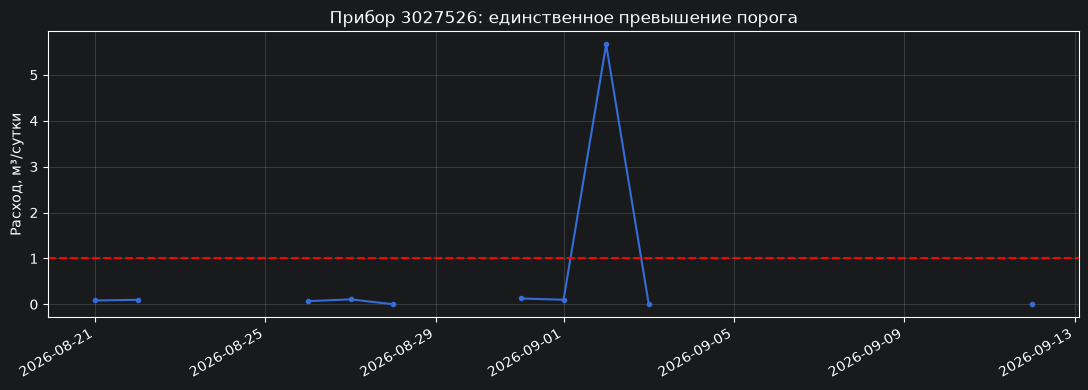

In [210]:
single_series = get_consumption_series(single_id)
peak_date = single_series.idxmax()

single_window = single_series.loc[
    peak_date - pd.Timedelta(days=14):
    peak_date + pd.Timedelta(days=14)
]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(single_window.index, single_window.values, marker=".")
ax.axhline(ABSOLUTE_THRESHOLD, color="red", linestyle="--")

ax.set_title(f"Прибор {single_id}: единственное превышение порога")
ax.set_ylabel("Расход, м³/сутки")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Регулярно высокий расход.** Выбирается прибор минимум с 60 наблюдениями и превышением 1 м³ хотя бы в половине дней, без существенных отрицательных разниц и экстремумов >10 м³.

In [211]:
regular_high_candidates = meter_profiles[
    meter_profiles["available_days"].ge(60)
    & meter_profiles["high_share"].ge(0.5)
    & meter_profiles["minimum_consumption"].ge(-EPS)
    & meter_profiles["maximum_consumption"].le(10)
].sort_values(
    ["high_share", "available_days"],
    ascending=False,
)

display(regular_high_candidates.head(3))

regular_id = regular_high_candidates.index[0]

,available_days,maximum_consumption,minimum_consumption,high_days,high_share
anon_id,,,,,
1648954,245,3.926,0.83381,241,0.983673
8975533,203,3.388,0.75200,194,0.955665
6353750,236,2.941,0.00000,225,0.953390


**График высокого уровня.** Если порог превышается почти постоянно, он плохо характеризует необычный день именно этого прибора. Для оценки нужны назначение объекта и индивидуальный фон.

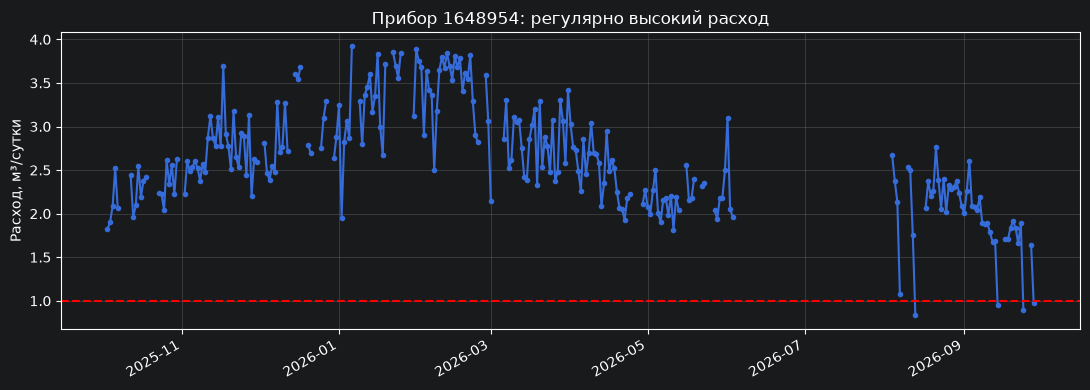

In [212]:
regular_series = get_consumption_series(regular_id)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(regular_series.index, regular_series.values, marker=".")
ax.axhline(ABSOLUTE_THRESHOLD, color="red", linestyle="--")

ax.set_title(f"Прибор {regular_id}: регулярно высокий расход")
ax.set_ylabel("Расход, м³/сутки")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Скачок и последующее падение.** Положительные и отрицательные суточные разницы показаны вместе. Большую компенсирующую пару нельзя автоматически трактовать как реальное использование воды.

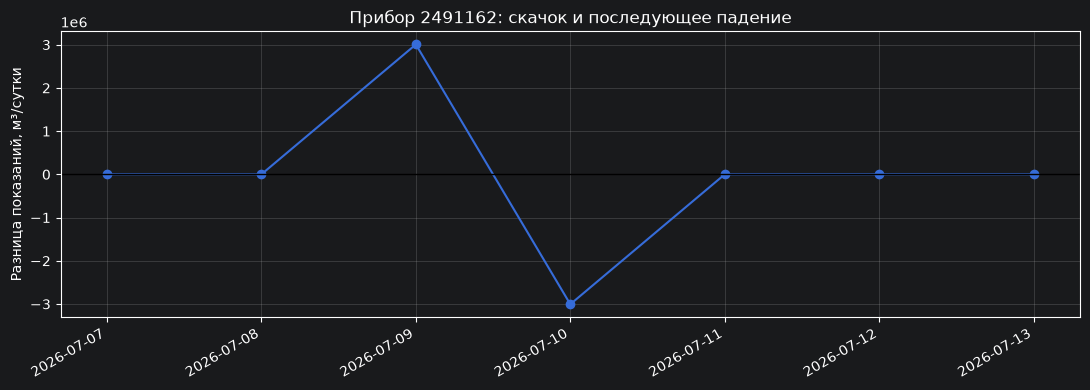

In [213]:
return_series = get_consumption_series(example_id)
return_window = return_series.loc[window_start:window_end]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(return_window.index, return_window.values, marker="o")
ax.axhline(0, color="black", linewidth=1)

ax.set_title(f"Прибор {example_id}: скачок и последующее падение")
ax.set_ylabel("Разница показаний, м³/сутки")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Интерпретация примеров.** У `3027526` единственное превышение достигает 5,663 м³. У `1648954` порог превышен в 241 из 245 доступных дней — это регулярно высокий уровень. У `2491162` положительный пик сопровождается падением. Одинаковый флаг «>1 м³» имеет разный смысл в этих трёх случаях.

## 8. Экстремальные значения и тип прибора

Расходы делятся на уровни >10, >100 и >1 000 м³/сутки. Затем исследуется их распределение по типам. Без паспортных характеристик и назначения объекта эти границы характеризуют экстремальность, а не установленную физическую невозможность.

**Уровни экстремальности.** Пороги 10, 100 и 1 000 м³ разделяют значения по масштабу. Физическая невозможность не установлена без пропускной способности прибора и назначения объекта.

In [214]:
extreme_summary = []

for threshold in [10, 100, 1000]:
    selected = daily[
        daily["daily_consumption"] > threshold
    ]

    extreme_summary.append({
        "Расход больше, м³/сутки": threshold,
        "Количество дней": len(selected),
        "Количество приборов": selected["anon_id"].nunique(),
    })

display(pd.DataFrame(extreme_summary))

,"Расход больше, м³/сутки",Количество дней,Количество приборов
0,10,379,63
1,100,281,55
2,1000,4,4


**Основная выборка экстремумов.** Сохраняются расходы >10 м³/сутки. Самые крупные значения показывают, какие приборы требуют первичной проверки исходных показаний.

In [215]:
EXTREME_THRESHOLD = 10.0

extreme_days = daily[
    daily["daily_consumption"] > EXTREME_THRESHOLD
].copy()

display(
    extreme_days.nlargest(10, "daily_consumption")[
        ["anon_id", "data", "daily_consumption"]
    ]
)

,anon_id,data,daily_consumption
442977,2491162,2026-07-09,3.005504e+06
455296,8908023,2026-09-07,2.684039e+06
397633,2159987,2025-10-17,2.834770e+03
266442,7891133,2025-10-17,2.124960e+03
282480,8973572,2025-10-17,6.081360e+02
393009,5359103,2026-07-05,5.303171e+02
92917,2030325,2026-07-20,4.259160e+02
457995,4964924,2026-09-20,4.010470e+02
386043,7247006,2026-09-29,3.640533e+02
268476,8498147,2026-09-29,3.639711e+02


**Сведения о приборах.** К расходам присоединяются станция, тип и модель. Объединение использует идентификатор и требует единственной строки справочника на прибор.

In [216]:
meter_details = meters[
    ["anon_id", "bs", "tip", "model"]
]

daily_with_info = daily.merge(
    meter_details,
    on="anon_id",
    how="left",
    validate="many_to_one",
)

**Контроль количества строк.** Число строк до и после объединения должно совпадать. Увеличение количества могло бы завысить число аномальных наблюдений.

In [217]:
print("До объединения:", len(daily))
print("После объединения:", len(daily_with_info))

До объединения: 616414
После объединения: 616414


**Экстремумы по типам.** Для дополнительного сравнения используется более строгая граница >100 м³. Число приборов с признаком сопоставляется с числом приборов каждого типа в справочнике.

In [218]:
very_extreme_days = daily_with_info[
    daily_with_info["daily_consumption"] > 100
].copy()

type_comparison = (
    meters.groupby("tip")["anon_id"]
    .nunique()
    .rename("total_meters")
    .to_frame()
)

extreme_meters_by_type = (
    very_extreme_days.groupby("tip")["anon_id"].nunique()
)

type_comparison["extreme_meters"] = (
    extreme_meters_by_type.reindex(
        type_comparison.index,
        fill_value=0,
    )
)

display(type_comparison)

,total_meters,extreme_meters
tip,,
AQUA2,391,55
aqua2_nvt_wa_stm,1595,0
aqua2_stm,1011,0
aqua2set_fudan_stm,3,0


**Доля внутри типа.** Расчёт процента учитывает разный размер групп. Он использует все приборы типа, но не уравнивает длительность и полноту их наблюдений.

In [219]:
type_comparison["extreme_percent"] = (
    type_comparison["extreme_meters"]
    / type_comparison["total_meters"]
    * 100
)

plot_data = type_comparison.sort_values(
    "extreme_percent",
    ascending=False,
)

**График различий типов.** Высота столбца — доля приборов типа с хотя бы одним расходом >100 м³. Это доля найденного признака, а не доказанных неисправностей.

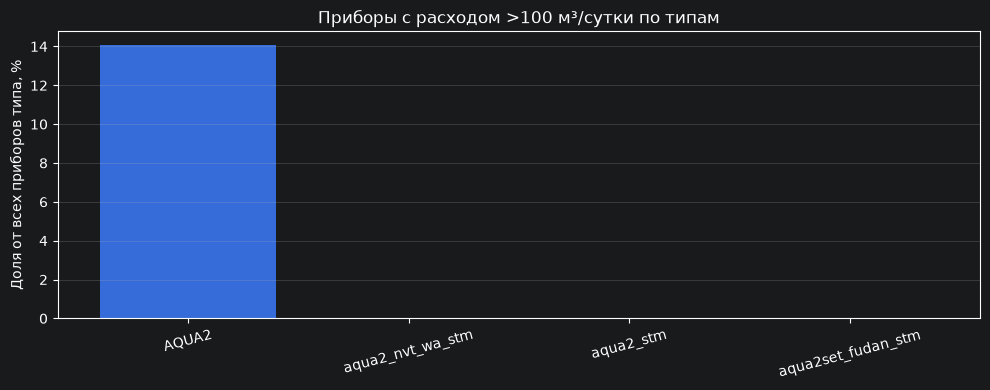

In [220]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    plot_data.index,
    plot_data["extreme_percent"],
)

ax.set_title("Приборы с расходом >100 м³/сутки по типам")
ax.set_ylabel("Доля от всех приборов типа, %")
ax.tick_params(axis="x", labelrotation=15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Экстремумы без крупнейших пиков.** Диапазон 100–1 000 м³ позволяет увидеть менее заметные случаи за пределами четырёх крупнейших значений. Исходные значения из расчёта не удаляются.

In [221]:
moderate_extremes = very_extreme_days[
    very_extreme_days["daily_consumption"].le(1000)
]

display(
    moderate_extremes.nlargest(15, "daily_consumption")[
        [
            "anon_id",
            "data",
            "daily_consumption",
            "tip",
            "bs",
            "model",
        ]
    ]
)

,anon_id,data,daily_consumption,tip,bs,model
548542,8973572,2025-10-17,608.136000,AQUA2,BS-05,NaN
299278,5359103,2026-07-05,530.317143,AQUA2,BS-07,АКВА L110 D15 B E
77619,2030325,2026-07-20,425.916000,AQUA2,BS-03,АКВА L110 D15 B E
277429,4964924,2026-09-20,401.047026,AQUA2,BS-07,АКВА L110 D15 B E
429658,7247006,2026-09-29,364.053333,AQUA2,BS-07,АКВА L110 D15 B E
520666,8498147,2026-09-29,363.971111,AQUA2,BS-05,АКВА L110 D15 C E
77668,2030325,2026-09-07,352.825385,AQUA2,BS-03,АКВА L110 D15 B E
77637,2030325,2026-08-07,352.655903,AQUA2,BS-03,АКВА L110 D15 B E
37386,1423304,2026-09-08,343.224762,AQUA2,BS-07,NaN
37389,1423304,2026-09-11,342.294375,AQUA2,BS-07,NaN


**Результат по экстремумам.** >10 м³ найдено у 63 приборов, >100 — у 55, >1 000 — у четырёх. Все 55 приборов с >100 м³ относятся к `AQUA2`: 55 из 391, около 14,1%. Это направление технической проверки, но различия назначения объектов и полноты данных не устранены.

## 9. Большой скачок с последующим падением

Ищутся положительные расходы >100 м³, за которыми в течение трёх календарных дней следует отрицательная суточная разница с модулем не меньше 80% скачка. Это признак для технической проверки; совпадение не гарантирует точный возврат на прежнее показание.

**Частота экстремальных дней.** Определяется, у каких приборов экстремумы повторяются. Повторение требует проверки общего механизма, а не только отдельной записи.

In [222]:
extreme_frequency = (
    very_extreme_days
    .groupby("anon_id")
    .agg(
        extreme_days=("daily_consumption", "size"),
        maximum_consumption=("daily_consumption", "max"),
    )
    .sort_values("extreme_days", ascending=False)
    .reset_index()
)

display(extreme_frequency.head(10))

,anon_id,extreme_days,maximum_consumption
0,2030325,32,425.916000
1,8190741,19,327.996000
2,7293232,16,327.670000
3,1423304,14,343.224762
4,9487974,14,327.871000
5,6949939,11,327.670000
6,5704914,11,327.953000
7,3832684,9,327.670000
8,1492831,9,286.692500
9,2351232,9,327.670000


**Таблицы скачков и падений.** Даты и величины переименованы, чтобы различать положительный скачок и отрицательную разницу после объединения.

In [223]:
peaks = very_extreme_days[
    ["anon_id", "data", "daily_consumption"]
].rename(columns={
    "data": "peak_date",
    "daily_consumption": "peak_consumption",
})

drops = negative_daily[
    ["anon_id", "data", "daily_consumption"]
].rename(columns={
    "data": "drop_date",
    "daily_consumption": "drop_consumption",
})

**Поиск во временном окне.** Для каждого скачка ищется отрицательная суточная разница через один, два и три календарных дня. Неизвестный расход на дату не считается падением.

In [224]:
matched_parts = []

for days_after in [1, 2, 3]:
    peaks_to_check = peaks.copy()

    peaks_to_check["check_date"] = (
        peaks_to_check["peak_date"]
        + pd.Timedelta(days=days_after)
    )

    matched = peaks_to_check.merge(
        drops,
        left_on=["anon_id", "check_date"],
        right_on=["anon_id", "drop_date"],
        how="inner",
        validate="many_to_one",
    )

    matched_parts.append(matched)

possible_pairs = pd.concat(matched_parts, ignore_index=True)

**Сопоставимость величин.** Модуль падения делится на размер скачка. Сохраняются отношения ≥0,8; значение больше единицы допустимо и не означает точный возврат к прежнему уровню.

In [225]:
possible_pairs["drop_to_peak_ratio"] = (
    possible_pairs["drop_consumption"].abs()
    / possible_pairs["peak_consumption"]
)

MIN_DROP_RATIO = 0.8

spike_drop_pairs = possible_pairs[
    possible_pairs["drop_to_peak_ratio"].ge(MIN_DROP_RATIO)
].copy()

**Первое подходящее падение.** У каждого скачка остаётся первое подходящее падение. Несколько скачков могут иметь одно общее падение, поэтому найденные пары не являются независимыми эпизодами.

In [226]:
spike_drop_pairs = (
    spike_drop_pairs
    .sort_values(["anon_id", "peak_date", "drop_date"])
    .drop_duplicates(subset=["anon_id", "peak_date"])
)

print("Найдено пар:", len(spike_drop_pairs))
print("Приборов:", spike_drop_pairs["anon_id"].nunique())

Найдено пар: 144
Приборов: 37


**Примеры пар.** Показываются положительный пик и последующая отрицательная разница с датами. Совпадение по времени и величине — основание для проверки, но не доказательство механизма.

In [227]:
display(
    spike_drop_pairs.nlargest(10, "peak_consumption")[
        [
            "anon_id",
            "peak_date",
            "peak_consumption",
            "drop_date",
            "drop_consumption",
            "drop_to_peak_ratio",
        ]
    ]
)

,anon_id,peak_date,peak_consumption,drop_date,drop_consumption,drop_to_peak_ratio
15,2491162,2026-07-09,3.005504e+06,2026-07-10,-3.006487e+06,1.000327
46,8908023,2026-09-07,2.684039e+06,2026-09-08,-2.684367e+06,1.000122
72,2159987,2025-10-17,2.834770e+03,2025-10-19,-2.949060e+03,1.040317
94,7891133,2025-10-17,2.124960e+03,2025-10-19,-2.293389e+03,1.079262
63,2030325,2026-07-20,4.259160e+02,2026-07-22,-9.830813e+02,2.308158
119,4964924,2026-09-20,4.010470e+02,2026-09-23,-9.831857e+02,2.451547
68,2030325,2026-09-07,3.528254e+02,2026-09-09,-9.830441e+02,2.786206
58,1423304,2026-09-11,3.422944e+02,2026-09-13,-1.310846e+03,3.829586
64,2030325,2026-08-10,3.412742e+02,2026-08-12,-1.310742e+03,3.840730
80,4964924,2026-09-21,3.347866e+02,2026-09-23,-9.831857e+02,2.936754


**Приборы с повторяющимися парами.** Ранжирование по числу пар выбирает пример систематического поведения. Количество пар не равно числу независимых неисправностей.

In [228]:
pairs_by_meter = (
    spike_drop_pairs
    .groupby("anon_id")
    .size()
    .sort_values(ascending=False)
)

display(pairs_by_meter.head(10).rename("Количество пар"))

repeated_id = pairs_by_meter.index[0]

anon_id
2030325    20
9487974    10
7293232     9
8190741     8
1492831     7
2351232     6
4964924     6
6949939     6
5704914     5
6778798     5
Name: Количество пар, dtype: int64

**График повторений.** Чередование пиков и провалов показывает, повторяется ли рисунок в разные даты. Разрывы линии обозначают неизвестные суточные расходы.

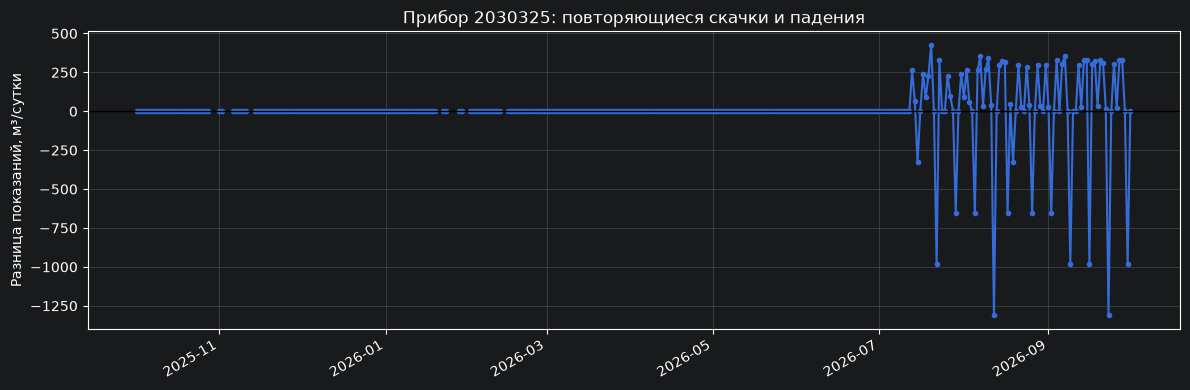

In [229]:
repeated_series = get_consumption_series(repeated_id)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(repeated_series.index, repeated_series.values, marker=".")
ax.axhline(0, color="black", linewidth=1)

ax.set_title(f"Прибор {repeated_id}: повторяющиеся скачки и падения")
ax.set_ylabel("Разница показаний, м³/сутки")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Дополнительная находка.** Найдено 144 пары «большой скачок — последующее падение» у 37 приборов. Один провал может соответствовать нескольким предшествующим скачкам; число пар не трактуется как число независимых эпизодов.

## 10. Длительные положительные серии

Выделяются последовательные сутки с положительным расходом. Основной порог — 30 дней; дополнительно рассматриваются 14, 60 и 90 дней. Это кандидаты на проверку утечки. Подтверждение непрерывного потока требует внутрисуточных наблюдений.

**Положительный день.** Отмечаются только известные суточные расходы >EPS. Ноль, отрицательная разница и пропуск прерывают подтверждённую положительную серию.

In [230]:
run_data = readings_sorted.reset_index(drop=True).copy()

run_data["positive_day"] = (
    run_data["daily_consumption"].gt(EPS)
)

display(
    run_data[
        ["anon_id", "data", "daily_consumption", "positive_day"]
    ].head(10)
)

,anon_id,data,daily_consumption,positive_day
0,1001589,2025-10-01,NaN,False
1,1001589,2025-10-02,0.080,True
2,1001589,2025-10-03,0.024,True
3,1001589,2025-10-04,0.046,True
4,1001589,2025-10-05,0.220,True
5,1001589,2025-10-06,0.050,True
6,1001589,2025-10-07,0.160,True
7,1001589,2025-10-08,0.020,True
8,1001589,2025-10-09,0.050,True
9,1001589,2025-10-10,0.037,True


**Состояние предыдущего дня.** Для каждого прибора определяется, была ли предыдущая запись положительной. Первая запись не имеет предшествующего положительного дня.

In [231]:
run_data["previous_positive"] = (
    run_data
    .groupby("anon_id")["positive_day"]
    .shift(1, fill_value=False)
)

**Начало положительной серии.** Новый положительный день начинает серию после неподходящей записи или календарного разрыва. Последовательные дни получают общий номер серии.

In [232]:
run_data["positive_run_start"] = (
    run_data["positive_day"]
    & (
        ~run_data["previous_positive"]
        | run_data["days_between"].ne(1)
    )
)

run_data["positive_run_id"] = (
    run_data["positive_run_start"].cumsum()
)

**Таблица положительных серий.** Длина серии, её медиана и максимум описывают режим. Число дней >10 м³ помогает увидеть серии, содержащие уже известные проблемы показаний.

In [233]:
run_data["extreme_day"] = (
    run_data["daily_consumption"].gt(EXTREME_THRESHOLD)
)

positive_days = run_data[
    run_data["positive_day"]
]

positive_runs = (
    positive_days
    .groupby(["anon_id", "positive_run_id"])
    .agg(
        start_date=("data", "min"),
        end_date=("data", "max"),
        days=("data", "size"),
        median_consumption=("daily_consumption", "median"),
        maximum_consumption=("daily_consumption", "max"),
        extreme_days=("extreme_day", "sum"),
    )
    .reset_index()
)

display(positive_runs.head())

,anon_id,positive_run_id,start_date,end_date,days,median_consumption,maximum_consumption,extreme_days
0,1001589,1,2025-10-02,2025-10-11,10,0.048,0.220,0
1,1001589,2,2025-10-13,2025-10-13,1,0.080,0.080,0
2,1001589,3,2025-10-16,2025-10-22,7,0.061,0.130,0
3,1001589,4,2025-10-24,2025-10-25,2,0.045,0.074,0
4,1001589,5,2025-10-31,2025-10-31,1,0.034,0.034,0


**Календарная непрерывность.** Проверяется совпадение числа дней серии с длиной календарного промежутка. При уникальной записи на дату это подтверждает отсутствие внутренних пропусков.

In [234]:
calendar_length = (
    positive_runs["end_date"]
    - positive_runs["start_date"]
).dt.days + 1

print(
    "Все серии непрерывны:",
    calendar_length.eq(positive_runs["days"]).all(),
)

Все серии непрерывны: True


**Влияние длины серии.** Сравнение 14, 30, 60 и 90 дней показывает, насколько широко условие. Один прибор может иметь несколько серий, поэтому приводятся оба количества.

In [235]:
run_threshold_results = []

for threshold in [14, 30, 60, 90]:
    selected_runs = positive_runs[
        positive_runs["days"].ge(threshold)
    ]

    run_threshold_results.append({
        "Минимум дней подряд": threshold,
        "Количество серий": len(selected_runs),
        "Количество приборов": selected_runs["anon_id"].nunique(),
    })

display(pd.DataFrame(run_threshold_results))

,Минимум дней подряд,Количество серий,Количество приборов
0,14,6861,1596
1,30,2664,1168
2,60,907,596
3,90,404,322


**Кандидаты на проверку утечки.** Основной критерий — ≥30 положительных дней подряд. Такие серии могут возникать при обычном ежедневном использовании воды, поэтому не называются подтверждённой утечкой.

In [236]:
MIN_POSITIVE_RUN_DAYS = 30

leak_candidates = positive_runs[
    positive_runs["days"].ge(MIN_POSITIVE_RUN_DAYS)
].copy()

display(
    leak_candidates.sort_values(
        "days",
        ascending=False,
    ).head(10)
)

,anon_id,positive_run_id,start_date,end_date,days,median_consumption,maximum_consumption,extreme_days
6280,1968874,6281,2025-10-02,2026-10-01,365,0.244000,0.688667,0
11916,2931056,11917,2025-10-02,2026-09-30,364,0.341500,0.742000,0
36777,7496751,36778,2025-10-02,2026-09-30,364,0.197449,0.493000,0
31782,6554606,31783,2025-10-02,2026-09-19,353,0.100000,0.433000,0
2122,1282534,2123,2025-10-02,2026-08-29,332,0.086000,0.528000,0
37536,7619242,37537,2025-10-02,2026-08-24,327,0.025000,0.261000,0
7351,2148838,7352,2025-11-11,2026-09-30,324,0.080000,2.530000,0
30817,6347187,30818,2025-11-13,2026-09-30,322,0.387774,1.999000,0
32960,6818785,32961,2025-10-31,2026-09-14,319,0.158000,0.391000,0
28927,5984218,28928,2025-10-02,2026-08-05,308,0.136000,0.506000,0


**График самой длинной серии.** Оранжевая область отмечает подтверждённый период положительного расхода. График показывает сутки, но не непрерывность потока внутри суток.

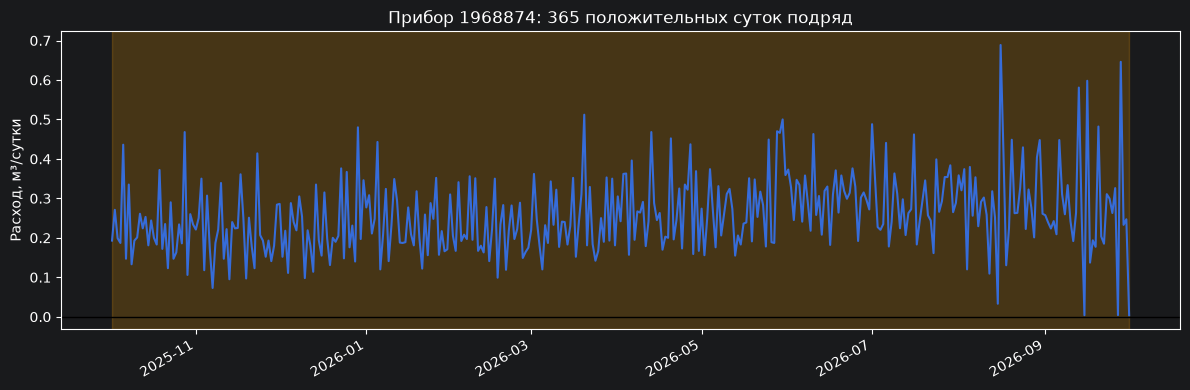

In [237]:
longest_run = positive_runs.loc[
    positive_runs["days"].idxmax()
]

longest_series = get_consumption_series(
    longest_run["anon_id"]
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(longest_series.index, longest_series.values)
ax.axhline(0, color="black", linewidth=1)

ax.axvspan(
    longest_run["start_date"],
    longest_run["end_date"],
    color="orange",
    alpha=0.2,
)

ax.set_title(
    f"Прибор {longest_run['anon_id']}: "
    f"{longest_run['days']} положительных суток подряд"
)
ax.set_ylabel("Расход, м³/сутки")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Результат по положительным сериям.** При пороге 30 суток найдено 2 664 серии у 1 168 приборов; при пороге 90 суток — 404 серии у 322 приборов. Самая длинная серия у `1968874` длится 365 дней. Критерий широкий: ежедневное использование воды может быть нормальным. Для подтверждения утечки нужны более частые измерения и контекст объекта.

## 11. Нулевые серии при поступлении пакетов

Ищется длительное неизменное показание при положительном количестве пакетов каждый день. Основной порог — 14 суток. Пустующий объект и остановка измерительного механизма могут давать похожие данные; для различения нужен контекст.

**Ноль при пакетах.** День подходит, если расход известен и близок к нулю, а пакеты положительны. Отсутствующее значение расхода не становится нулём.

In [238]:
run_data["zero_with_packets"] = (
    run_data["daily_consumption"].abs().le(EPS)
    & run_data["paketov_za_sutki"].gt(0)
)

display(
    run_data[
        [
            "anon_id",
            "data",
            "daily_consumption",
            "paketov_za_sutki",
            "zero_with_packets",
        ]
    ].head(10)
)

,anon_id,data,daily_consumption,paketov_za_sutki,zero_with_packets
0,1001589,2025-10-01,NaN,1,False
1,1001589,2025-10-02,0.080,1,False
2,1001589,2025-10-03,0.024,2,False
3,1001589,2025-10-04,0.046,1,False
4,1001589,2025-10-05,0.220,1,False
5,1001589,2025-10-06,0.050,1,False
6,1001589,2025-10-07,0.160,1,False
7,1001589,2025-10-08,0.020,1,False
8,1001589,2025-10-09,0.050,1,False
9,1001589,2025-10-10,0.037,3,False


**Начало нулевой серии.** Серия начинается после неподходящего дня или разрыва дат. Условие передачи пакетов проверяется каждый день, а не только в начале серии.

In [239]:
run_data["previous_zero_with_packets"] = (
    run_data
    .groupby("anon_id")["zero_with_packets"]
    .shift(1, fill_value=False)
)

run_data["zero_run_start"] = (
    run_data["zero_with_packets"]
    & (
        ~run_data["previous_zero_with_packets"]
        | run_data["days_between"].ne(1)
    )
)

run_data["zero_run_id"] = run_data["zero_run_start"].cumsum()

**Таблица нулевых серий.** Минимум пакетов подтверждает их поступление каждый день; сумма показывает передачу за весь период. Сами пакеты не доказывают исправность измерительной части.

In [240]:
zero_days = run_data[
    run_data["zero_with_packets"]
]

zero_runs = (
    zero_days
    .groupby(["anon_id", "zero_run_id"])
    .agg(
        start_date=("data", "min"),
        end_date=("data", "max"),
        days=("data", "size"),
        minimum_packets=("paketov_za_sutki", "min"),
        total_packets=("paketov_za_sutki", "sum"),
    )
    .reset_index()
)

display(zero_runs.head())

,anon_id,zero_run_id,start_date,end_date,days,minimum_packets,total_packets
0,1001589,1,2025-10-12,2025-10-12,1,1,1
1,1001589,2,2025-10-14,2025-10-15,2,1,2
2,1001589,3,2025-10-23,2025-10-23,1,1,1
3,1001589,4,2025-10-26,2025-10-30,5,1,5
4,1001589,5,2025-11-01,2025-11-01,1,1,1


**Влияние длительности нуля.** Сравниваются серии от 14 до 90 дней. Более длительный ноль требует контекста использования объекта, но тоже может быть нормальным отсутствием потребления.

In [241]:
zero_threshold_results = []

for threshold in [14, 30, 60, 90]:
    selected_runs = zero_runs[
        zero_runs["days"].ge(threshold)
    ]

    zero_threshold_results.append({
        "Минимум дней подряд": threshold,
        "Количество серий": len(selected_runs),
        "Количество приборов": selected_runs["anon_id"].nunique(),
    })

display(pd.DataFrame(zero_threshold_results))

,Минимум дней подряд,Количество серий,Количество приборов
0,14,3206,1099
1,30,1242,694
2,60,427,348
3,90,213,196


**Основной критерий нуля.** Сохраняются серии ≥14 дней. Если серия заканчивается вместе с наблюдениями, её длительность является нижней границей, а не установленной полной продолжительностью.

In [242]:
MIN_ZERO_RUN_DAYS = 14

zero_candidates = zero_runs[
    zero_runs["days"].ge(MIN_ZERO_RUN_DAYS)
].copy()

display(
    zero_candidates.sort_values(
        "days",
        ascending=False,
    ).head(10)
)

,anon_id,zero_run_id,start_date,end_date,days,minimum_packets,total_packets
37212,9686922,37213,2025-10-02,2026-09-30,364,1,454
28280,7558835,28281,2025-10-02,2026-09-30,364,1,451
36098,9354769,36099,2025-10-02,2026-09-26,360,1,443
19363,5374718,19364,2025-11-05,2026-10-01,331,1,2574
3082,1547698,3083,2025-10-02,2026-08-19,322,1,370
17934,4954627,17935,2025-12-19,2026-09-30,286,1,841
1132,1201898,1133,2025-10-02,2026-07-02,274,1,274
23506,6323493,23507,2025-10-02,2026-06-26,268,1,268
18106,5012389,18107,2026-01-17,2026-09-30,257,1,347
1419,1263288,1420,2026-01-18,2026-09-30,256,1,342


**Выбор подробного примера.** Выбирается самая длинная нулевая серия и история соответствующего прибора. При равных длинах выбор зависит от порядка строк.

In [243]:
longest_zero_run = zero_runs.loc[
    zero_runs["days"].idxmax()
]

zero_example_id = longest_zero_run["anon_id"]

zero_example = readings_sorted[
    readings_sorted["anon_id"].eq(zero_example_id)
].copy()

print("Прибор:", zero_example_id)
print("Длина серии:", longest_zero_run["days"], "дней")

Прибор: 7558835
Длина серии: 364 дней


**Неизменное показание.** Горизонтальный участок подтверждает отсутствие зарегистрированного увеличения счётчика. Он не различает пустующий объект и остановку измерения.

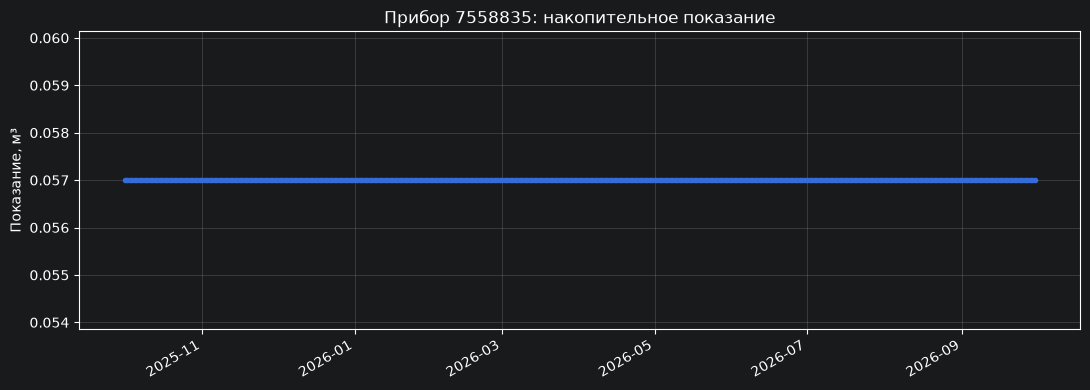

In [244]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    zero_example["data"],
    zero_example["pokazanie"],
    marker=".",
)

ax.set_title(f"Прибор {zero_example_id}: накопительное показание")
ax.set_ylabel("Показание, м³")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Поступление пакетов.** Точки показывают количество пакетов на наблюдаемые даты; линия между отсутствующими датами не достраивается. Вместе с предыдущим графиком подтверждается сочетание «показание стоит, данные поступают».

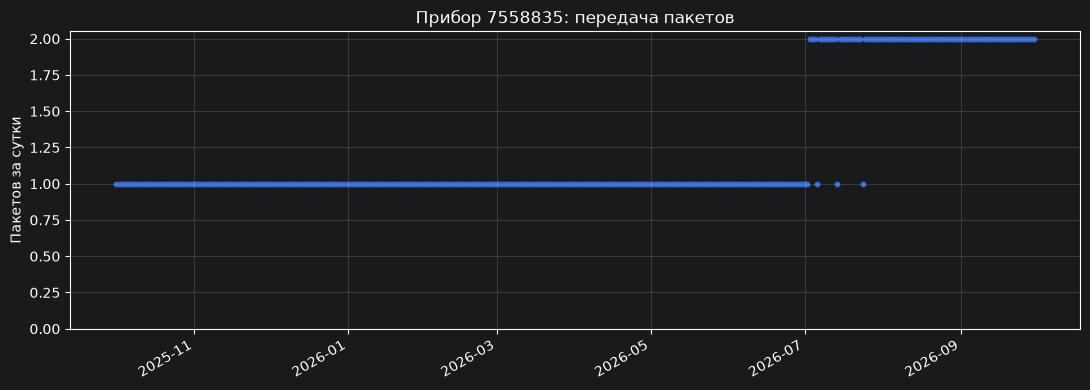

In [245]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.scatter(
    zero_example["data"],
    zero_example["paketov_za_sutki"],
    s=10,
)

ax.set_title(f"Прибор {zero_example_id}: передача пакетов")
ax.set_ylabel("Пакетов за сутки")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Результат по нулевым сериям.** При пороге 14 суток найдено 3 206 серий у 1 099 приборов; от 90 суток — 213 серий у 196 приборов. У `7558835` и `9686922` подтверждено по 364 нулевых дня при пакетах. Если наблюдения заканчиваются, неизвестно, когда фактически завершилась серия.

## 12. Устойчивое изменение уровня потребления

Сначала сравниваются половины собственного календарного периода прибора, затем проверяются покрытие и медианы четвертей. Критерий выделяет устойчивое различие частей периода, но не определяет точную дату перехода и не исключает сезонность.

**Расход для анализа уровня.** Нули сохраняются, отрицательные разницы исключаются. Большие положительные значения пока остаются, поэтому сравниваются среднее и более устойчивые медианы.

In [246]:
step_data = daily[
    daily["daily_consumption"].ge(-EPS)
].copy()

step_data["daily_consumption"] = (
    step_data["daily_consumption"].clip(lower=0)
)

**Собственный период прибора.** Границы определяются по всем его показаниям. Общая граница набора была бы некорректной для приборов с короткой историей.

In [247]:
meter_periods = (
    readings_sorted
    .groupby("anon_id")
    .agg(
        first_date=("data", "min"),
        last_date=("data", "max"),
    )
)

meter_periods["calendar_days"] = (
    meter_periods["last_date"]
    - meter_periods["first_date"]
).dt.days + 1

**Половины календарного периода.** Делится длительность в днях, а не количество строк. Дата разделения принадлежит второй половине; она не является найденной датой изменения расхода.

In [248]:
meter_periods["split_date"] = (
    meter_periods["first_date"]
    + pd.to_timedelta(
        meter_periods["calendar_days"] // 2,
        unit="D",
    )
)

step_data = step_data.merge(
    meter_periods,
    on="anon_id",
    how="left",
    validate="many_to_one",
)

step_data["half"] = "Первая"

step_data.loc[
    step_data["data"].ge(step_data["split_date"]),
    "half",
] = "Вторая"

**Среднее и медиана половин.** Различие среднего без изменения медианы может объясняться отдельными пиками. Количество доступных дней показывает основу каждого расчёта.

In [249]:
half_stats = (
    step_data
    .groupby(["anon_id", "half"])
    .agg(
        mean_consumption=("daily_consumption", "mean"),
        median_consumption=("daily_consumption", "median"),
        available_days=("daily_consumption", "size"),
    )
    .reset_index()
)

display(half_stats.head(10))

,anon_id,half,mean_consumption,median_consumption,available_days
0,1001589,Вторая,0.033148,0.0200,183
1,1001589,Первая,0.037440,0.0155,134
2,1009827,Вторая,0.146182,0.1200,169
3,1009827,Первая,0.152093,0.1400,161
4,1010676,Вторая,0.000000,0.0000,12
5,1010676,Первая,0.000000,0.0000,61
6,1013205,Вторая,0.071192,0.0720,177
7,1013205,Первая,0.080929,0.0755,156
8,1017147,Вторая,0.000000,0.0000,6
9,1017147,Первая,0.000000,0.0000,6


**Показатели рядом.** Медианы и числа дней преобразуются в отдельные столбцы половин. Такое представление упрощает сравнение одного прибора.

In [250]:
median_halves = half_stats.pivot(
    index="anon_id",
    columns="half",
    values="median_consumption",
)

days_halves = half_stats.pivot(
    index="anon_id",
    columns="half",
    values="available_days",
)

display(median_halves.head())

half,Вторая,Первая
anon_id,,
1001589,0.020,0.0155
1009827,0.120,0.1400
1010676,0.000,0.0000
1013205,0.072,0.0755
1017147,0.000,0.0000


**Первичный отбор по числу дней.** Требуется минимум 30 расходов в каждой половине. Разница медиан показывает направление изменения; достаточное число строк ещё не гарантирует хорошего покрытия календаря.

In [251]:
MIN_DAYS_PER_HALF = 30

enough_days = (
    days_halves["Первая"].ge(MIN_DAYS_PER_HALF)
    & days_halves["Вторая"].ge(MIN_DAYS_PER_HALF)
)

half_comparison = median_halves.loc[enough_days].copy()

half_comparison["change"] = (
    half_comparison["Вторая"]
    - half_comparison["Первая"]
)

half_comparison["absolute_change"] = (
    half_comparison["change"].abs()
)

print("Приборов для сравнения:", len(half_comparison))

display(
    half_comparison.sort_values(
        "absolute_change",
        ascending=False,
    ).head(10)
)

Приборов для сравнения: 2318


half,Вторая,Первая,change,absolute_change
anon_id,,,,
1581018,2.440218,0.0540,2.386218,2.386218
3761383,1.991000,0.0000,1.991000,1.991000
5927111,4.140851,2.6890,1.451851,1.451851
4918146,2.173030,0.9920,1.181030,1.181030
3743114,0.956000,0.0050,0.951000,0.951000
7093326,1.423700,2.2205,-0.796800,0.796800
1648954,2.178000,2.8695,-0.691500,0.691500
7629899,0.659000,0.0230,0.636000,0.636000
1401643,1.775000,2.3265,-0.551500,0.551500


**Пример большого изменения.** Выбирается крупнейшая абсолютная разница медиан среди первично пригодных приборов. Пример ещё не является подтверждённой ступенькой.

In [252]:
step_example_id = (
    half_comparison["absolute_change"].idxmax()
)

example_period = meter_periods.loc[step_example_id]
example_levels = half_comparison.loc[step_example_id]

step_series = get_consumption_series(step_example_id)

display(
    half_stats[
        half_stats["anon_id"].eq(step_example_id)
    ]
)

,anon_id,half,mean_consumption,median_consumption,available_days
441,1581018,Вторая,2.496465,2.440218,134
442,1581018,Первая,0.615959,0.054000,145


**График половин.** Чёрная вертикальная линия — техническое разделение периода, горизонтальные — медианы половин. Проверяется форма изменения: скачок, плавный переход, отдельный участок или пропуски.

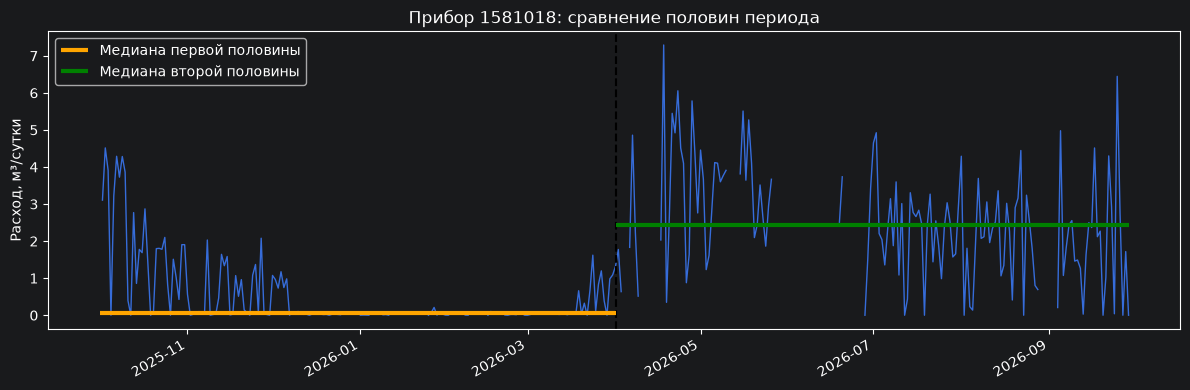

In [253]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(step_series.index, step_series.values, linewidth=1)

ax.axvline(
    example_period["split_date"],
    color="black",
    linestyle="--",
)

ax.hlines(
    example_levels["Первая"],
    example_period["first_date"],
    example_period["split_date"],
    color="orange",
    linewidth=3,
    label="Медиана первой половины",
)

ax.hlines(
    example_levels["Вторая"],
    example_period["split_date"],
    example_period["last_date"],
    color="green",
    linewidth=3,
    label="Медиана второй половины",
)

ax.set_title(f"Прибор {step_example_id}: сравнение половин периода")
ax.set_ylabel("Расход, м³/сутки")
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Ожидаемые календарные дни.** Для каждой половины определяется календарная длина. Она нужна как знаменатель полноты наблюдений, включая дни без пригодного расхода.

In [254]:
coverage = meter_periods.join(days_halves)

coverage["expected_first"] = (
    coverage["split_date"]
    - coverage["first_date"]
).dt.days

coverage["expected_second"] = (
    coverage["last_date"]
    - coverage["split_date"]
).dt.days + 1

**Покрытие половин.** Требуются ≥30 пригодных расходов и ≥70% покрытия каждой половины. Этот рабочий компромисс допускает пропуски, но не делает их случайными.

In [255]:
coverage["first_share"] = (
    coverage["Первая"]
    / coverage["expected_first"].replace(0, float("nan"))
)

coverage["second_share"] = (
    coverage["Вторая"]
    / coverage["expected_second"].replace(0, float("nan"))
)

MIN_COVERAGE = 0.70

reliable_halves = (
    coverage["Первая"].ge(MIN_DAYS_PER_HALF)
    & coverage["Вторая"].ge(MIN_DAYS_PER_HALF)
    & coverage["first_share"].ge(MIN_COVERAGE)
    & coverage["second_share"].ge(MIN_COVERAGE)
)

reliable_ids = coverage.index[reliable_halves]

print("Приборов с достаточным покрытием:", len(reliable_ids))

Приборов с достаточным покрытием: 1193


**Границы четвертей.** Каждая половина разделяется ещё пополам. Такой способ сохраняет согласованность четвертей с ранее выбранной границей половин.

In [256]:
meter_periods["quarter_2_start"] = (
    meter_periods["first_date"]
    + pd.to_timedelta(
        coverage["expected_first"] // 2,
        unit="D",
    )
)

meter_periods["quarter_4_start"] = (
    meter_periods["split_date"]
    + pd.to_timedelta(
        coverage["expected_second"] // 2,
        unit="D",
    )
)

**Номер четверти.** Каждая запись получает номер от 1 до 4. Более поздние назначения заменяют ранние, поэтому порядок условий важен.

In [257]:
step_data = step_data.merge(
    meter_periods[["quarter_2_start", "quarter_4_start"]],
    on="anon_id",
    how="left",
    validate="many_to_one",
)

step_data["quarter"] = 1

step_data.loc[
    step_data["data"].ge(step_data["quarter_2_start"]),
    "quarter",
] = 2

step_data.loc[
    step_data["data"].ge(step_data["split_date"]),
    "quarter",
] = 3

step_data.loc[
    step_data["data"].ge(step_data["quarter_4_start"]),
    "quarter",
] = 4

**Медианы четвертей.** Четыре уровня позволяют проверить, сохраняется ли различие в разных частях периода. Отдельно считается количество пригодных дней каждой четверти.

In [258]:
quarter_stats = (
    step_data
    .groupby(["anon_id", "quarter"])
    .agg(
        median_consumption=("daily_consumption", "median"),
        available_days=("daily_consumption", "size"),
    )
    .reset_index()
)

quarter_medians = quarter_stats.pivot(
    index="anon_id",
    columns="quarter",
    values="median_consumption",
).reindex(columns=[1, 2, 3, 4])

quarter_days = quarter_stats.pivot(
    index="anon_id",
    columns="quarter",
    values="available_days",
).reindex(columns=[1, 2, 3, 4])

**Достаточность четвертей.** Требуется минимум 10 наблюдений в каждой четверти и ранее установленное покрытие половин. Пропущенная четверть не считается нулевым уровнем.

In [259]:
MIN_DAYS_PER_QUARTER = 10

reliable_quarters = quarter_days.ge(
    MIN_DAYS_PER_QUARTER
).all(axis=1)

quarter_comparison = quarter_medians[
    quarter_medians.index.isin(reliable_ids)
    & reliable_quarters
].copy()

display(quarter_comparison.head())

quarter,1,2,3,4
anon_id,,,,
1001589,0.0100,0.0400,0.020,0.010000
1009827,0.1395,0.1400,0.140,0.102434
1013205,0.0725,0.0785,0.068,0.077527
1031366,0.0300,0.0070,0.020,0.017750
1036686,0.0000,0.0000,0.000,0.098923


**Консервативное сравнение уровней.** Для роста сравнивается меньшая поздняя медиана с большей ранней; для падения — наоборот. Обе четверти нового периода должны отличаться от обеих четвертей старого.

In [260]:
early_max = quarter_comparison[[1, 2]].max(axis=1)
early_min = quarter_comparison[[1, 2]].min(axis=1)

late_max = quarter_comparison[[3, 4]].max(axis=1)
late_min = quarter_comparison[[3, 4]].min(axis=1)

**Критерий устойчивого изменения.** Требуются ≥3× опорного уровня и абсолютное различие ≥0,1 м³. При фоне ниже 0,01 м³ применяется нижняя опорная граница; фактическая кратность роста от нуля не определяется.

In [261]:
STEP_FACTOR = 3
MIN_STEP_CHANGE = 0.1
STEP_REFERENCE_FLOOR = 0.01

growth = (
    late_min.ge(
        STEP_FACTOR * early_max.clip(lower=STEP_REFERENCE_FLOOR)
    )
    & (late_min - early_max).ge(MIN_STEP_CHANGE)
)

decline = (
    early_min.ge(
        STEP_FACTOR * late_max.clip(lower=STEP_REFERENCE_FLOOR)
    )
    & (early_min - late_max).ge(MIN_STEP_CHANGE)
)

**Кандидаты со ступенькой.** Сохраняются приборы с ростом или падением по заданным условиям. Это устойчивое различие частей периода, не автоматическое определение даты перехода или его причины.

In [262]:
quarter_comparison["direction"] = ""

quarter_comparison.loc[growth, "direction"] = "Рост"
quarter_comparison.loc[decline, "direction"] = "Падение"

step_candidates = quarter_comparison[
    quarter_comparison["direction"].ne("")
].copy()

print("Кандидатов:", len(step_candidates))
print("Рост:", growth.sum())
print("Падение:", decline.sum())

display(step_candidates)

Кандидатов: 14
Рост: 13
Падение: 1


quarter,1,2,3,4,direction
anon_id,,,,,
1581018,0.397,0.031,3.426000,2.204425,Рост
2194061,0.125,0.236,0.000000,0.000000,Падение
2567791,0.056,0.031,0.288000,0.327594,Рост
4273329,0.000,0.000,0.124000,0.110000,Рост
4414578,0.001,0.026,0.257000,0.199000,Рост
4520579,0.000,0.000,0.194500,0.175500,Рост
4565193,0.005,0.000,0.205000,0.277600,Рост
4701922,0.000,0.000,0.144000,0.135129,Рост
6343236,0.000,0.000,0.104000,0.184205,Рост


**Результат по уровню потребления.** После проверки покрытия и устойчивости найдено 14 кандидатов: 13 с ростом и один с падением. Например, медианы четвертей `9254821` равны примерно 0; 0; 0,289; 0,302 м³, а `2194061` — 0,125; 0,236; 0; 0. Переход от нуля нельзя описать конечной фактической кратностью. Даты и причины изменения проверяются по истории.

## 13. Магнитные события и расход до/после

Последовательные магнитные дни объединяются в эпизоды. Сравниваются семь дней до начала и семь после окончания, без дней самого эпизода. Отбор требует минимум пяти пригодных расходов в каждом окне и отсутствия других событий в окнах.

**Магнитные дни.** Отбираются уникальные магнитные даты. Количество сочетаний «прибор — дата» не равно числу независимых воздействий.

In [263]:
magnet_events = (
    events_daily[
        events_daily["sobytie"].eq("магнит")
    ]
    .sort_values(["anon_id", "data"])
    .reset_index(drop=True)
)

print("Дней с магнитным событием:", len(magnet_events))
print("Приборов:", magnet_events["anon_id"].nunique())

Дней с магнитным событием: 10164
Приборов: 671


**Магнит по календарю.** Считается число приборов с событием на дату. Полный календарь добавляет даты без зарегистрированных магнитных событий.

In [264]:
magnet_per_day = (
    magnet_events
    .groupby("data")["anon_id"]
    .nunique()
)

magnet_per_day = magnet_per_day.reindex(
    calendar,
    fill_value=0,
)

**График событий.** Подъём линии означает больше приборов с записью события. Он сам по себе не показывает влияние на расход и зависит от состава наблюдаемых приборов.

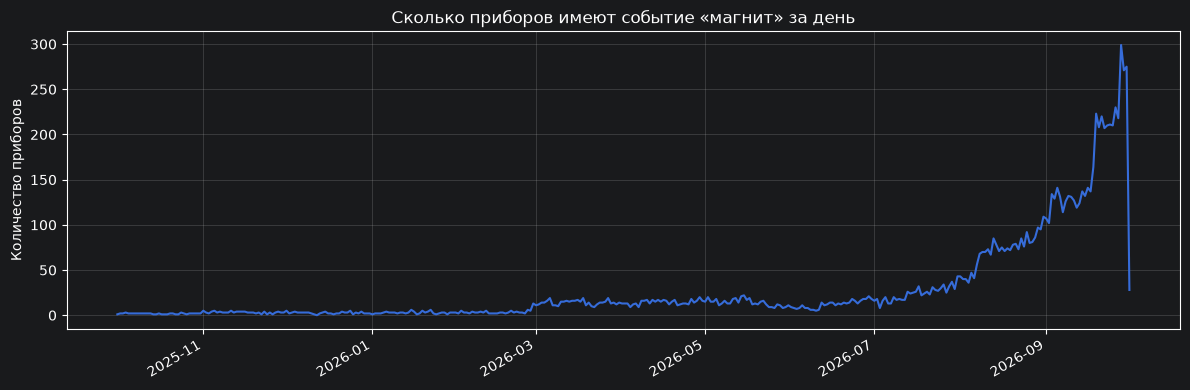

In [265]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(magnet_per_day.index, magnet_per_day.values)

ax.set_title("Сколько приборов имеют событие «магнит» за день")
ax.set_ylabel("Количество приборов")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Начало магнитного эпизода.** Последовательные даты одного прибора объединяются; разрыв больше суток начинает новый эпизод. Это правило группировки записей, а не измерение физической длительности воздействия.

In [266]:
magnet_events["days_since_previous"] = (
    magnet_events
    .groupby("anon_id")["data"]
    .diff()
    .dt.days
)

magnet_events["episode_start"] = (
    magnet_events["days_since_previous"].ne(1)
)

magnet_events["episode_id"] = (
    magnet_events["episode_start"].cumsum()
)

**Длительность эпизодов.** Таблица показывает начало, конец и число магнитных дней. Длинный эпизод может не иметь достаточных наблюдений до или после.

In [267]:
magnet_episodes = (
    magnet_events
    .groupby(["anon_id", "episode_id"])
    .agg(
        start_date=("data", "min"),
        end_date=("data", "max"),
        event_days=("data", "size"),
    )
    .reset_index()
)

print("Магнитных эпизодов:", len(magnet_episodes))

display(
    magnet_episodes.sort_values(
        "event_days",
        ascending=False,
    ).head(10)
)

Магнитных эпизодов: 3398


,anon_id,episode_id,start_date,end_date,event_days
1952,6148469,1953,2026-07-24,2026-10-01,70
896,3521717,897,2025-10-01,2025-11-25,56
1768,5828152,1769,2026-08-07,2026-09-30,55
1600,5339071,1601,2026-08-15,2026-09-30,47
2014,6335255,2015,2026-08-16,2026-09-30,46
2379,7364376,2380,2026-08-19,2026-09-30,43
1426,4830669,1427,2026-08-24,2026-09-30,38
366,2094607,367,2026-03-25,2026-04-30,37
131,1425344,132,2026-08-27,2026-10-01,36
2286,7093326,2287,2026-03-23,2026-04-26,35


**Наличие показания в день магнита.** Проверяется совпадение дат события и показания. `_merge` отличает отсутствие записи от случая, когда запись есть, но суточный расход неизвестен.

In [268]:
magnet_readings = magnet_events[
    ["anon_id", "data"]
].merge(
    readings_sorted[
        ["anon_id", "data", "daily_consumption"]
    ],
    on=["anon_id", "data"],
    how="left",
    validate="one_to_one",
    indicator=True,
)

**Доступность суточного расхода.** Разделяются три ситуации: нет показания, нет пригодного интервала и есть суточная разница. Отсутствующие значения не заменяются нулями при сопоставлении событий.

In [269]:
has_reading = magnet_readings["_merge"].eq("both")
has_daily_consumption = (
    magnet_readings["daily_consumption"].notna()
)

magnet_availability = pd.DataFrame({
    "Ситуация": [
        "Нет показания на дату события",
        "Показание есть, суточный расход неизвестен",
        "Суточный расход доступен",
    ],
    "Количество": [
        (~has_reading).sum(),
        (has_reading & ~has_daily_consumption).sum(),
        has_daily_consumption.sum(),
    ],
})

display(magnet_availability)

,Ситуация,Количество
0,Нет показания на дату события,4443
1,"Показание есть, суточный расход неизвестен",1110
2,Суточный расход доступен,4611


**Доступность событий и расхода.** В данных 10 164 магнитных дня у 671 прибора, объединённые в 3 398 эпизодов. Суточная разница известна на 4 611 магнитных датах. Отсутствующий расход не считается нулевым и ограничивает возможность сопоставления.

**Фоновый расход для события.** Для сравнения уровня исключаются отрицательные и >10 м³ расходы. Исходные значения сохраняются; исключённые аномалии исследуются отдельно в главе 15.

In [270]:
event_consumption = readings_sorted[
    ["anon_id", "data", "daily_consumption"]
].copy()

invalid_for_comparison = (
    event_consumption["daily_consumption"].lt(-EPS)
    | event_consumption["daily_consumption"].gt(EXTREME_THRESHOLD)
)

event_consumption["comparison_consumption"] = (
    event_consumption["daily_consumption"]
    .mask(invalid_for_comparison)
    .clip(lower=0)
)

**Окна до и после.** Создаются семь дат до начала и семь после конца эпизода. Дни самого события исключены, поскольку время срабатывания внутри суток неизвестно.

In [271]:
WINDOW_DAYS = 7
window_parts = []

for offset in range(1, WINDOW_DAYS + 1):
    before = magnet_episodes[
        ["anon_id", "episode_id", "start_date"]
    ].copy()

    before["data"] = (
        before["start_date"] - pd.Timedelta(days=offset)
    )
    before["period"] = "До"

    after = magnet_episodes[
        ["anon_id", "episode_id", "end_date"]
    ].copy()

    after["data"] = (
        after["end_date"] + pd.Timedelta(days=offset)
    )
    after["period"] = "После"

    window_parts.extend([before, after])

event_windows = pd.concat(window_parts, ignore_index=True)

**Расход в запланированные даты.** Левое объединение сохраняет все даты окна. Отсутствующее или исключённое значение уменьшает число пригодных наблюдений, а не медиану через искусственный ноль.

In [272]:
window_data = event_windows.merge(
    event_consumption[
        ["anon_id", "data", "comparison_consumption"]
    ],
    on=["anon_id", "data"],
    how="left",
    validate="many_to_one",
)

**Соседние события.** В окнах отмечаются все типы событий. Их присутствие может смешивать причины изменения, поэтому такие эпизоды позже исключаются из фонового сравнения.

In [273]:
event_dates = (
    events_daily[["anon_id", "data"]]
    .drop_duplicates()
    .assign(has_event=True)
)

window_data = window_data.merge(
    event_dates,
    on=["anon_id", "data"],
    how="left",
    validate="many_to_one",
)

window_data["has_event"] = window_data["has_event"].eq(True)

**Характеристики окон.** Для каждого окна считаются медиана, число непустых расходов и число дат с событиями. `count` учитывает только известные пригодные значения.

In [274]:
window_stats = (
    window_data
    .groupby(["anon_id", "episode_id", "period"])
    .agg(
        median_consumption=("comparison_consumption", "median"),
        available_days=("comparison_consumption", "count"),
        event_days=("has_event", "sum"),
    )
    .reset_index()
)

display(window_stats.head(10))

,anon_id,episode_id,period,median_consumption,available_days,event_days
0,1017147,1,До,NaN,0,0
1,1017147,1,После,0.0,2,1
2,1017147,2,До,0.0,2,1
3,1017147,2,После,0.0,3,0
4,1017147,3,До,0.0,5,0
5,1017147,3,После,0.0,1,4
6,1017147,4,До,0.0,2,4
7,1017147,4,После,0.0,1,5
8,1017147,5,До,NaN,0,5
9,1017147,5,После,NaN,0,6


**Показатели до.** Столбцы переименованы, чтобы явно отличать исходный уровень от последующего. Сохраняются идентификаторы прибора и эпизода.

In [275]:
before_stats = window_stats[
    window_stats["period"].eq("До")
].rename(columns={
    "median_consumption": "median_before",
    "available_days": "days_before",
    "event_days": "events_before",
}).drop(columns="period")

**Показатели после.** Окна соединяются по одному эпизоду. Проверка уникальности предотвращает размножение результатов сравнения.

In [276]:
after_stats = window_stats[
    window_stats["period"].eq("После")
].rename(columns={
    "median_consumption": "median_after",
    "available_days": "days_after",
    "event_days": "events_after",
}).drop(columns="period")

magnet_comparison = before_stats.merge(
    after_stats,
    on=["anon_id", "episode_id"],
    validate="one_to_one",
)

**Пригодные магнитные эпизоды.** Нужно ≥5 расходов из 7 в каждом окне и отсутствие других событий в обоих окнах. Результат относится только к прошедшим этот отбор эпизодам.

In [277]:
MIN_WINDOW_OBSERVATIONS = 5

magnet_comparison = magnet_comparison[
    magnet_comparison["days_before"].ge(MIN_WINDOW_OBSERVATIONS)
    & magnet_comparison["days_after"].ge(MIN_WINDOW_OBSERVATIONS)
    & magnet_comparison["events_before"].eq(0)
    & magnet_comparison["events_after"].eq(0)
].copy()

print("Пригодных эпизодов:", len(magnet_comparison))
print("Приборов:", magnet_comparison["anon_id"].nunique())

Пригодных эпизодов: 101
Приборов: 79


**Критерий падения после магнита.** Медиана до ≥0,02 м³, после ≤50% уровня до, снижение ≥0,02 м³. Это наблюдаемое изменение, а не установленное влияние магнита.

In [278]:
MIN_EVENT_CHANGE = 0.02
MAX_AFTER_FRACTION = 0.5

magnet_comparison["consumption_drop"] = (
    magnet_comparison["median_before"].ge(MIN_EVENT_CHANGE)
    & magnet_comparison["median_after"].le(
        magnet_comparison["median_before"] * MAX_AFTER_FRACTION
    )
    & (
        magnet_comparison["median_before"]
        - magnet_comparison["median_after"]
    ).ge(MIN_EVENT_CHANGE)
)

magnet_drops = magnet_comparison[
    magnet_comparison["consumption_drop"]
].copy()

display(magnet_drops)

,anon_id,episode_id,median_before,days_before,events_before,median_after,days_after,events_after,consumption_drop
1166,4183513,1167,0.028000,7,0,0.000,7,0,True
1710,5529203,1711,0.041129,7,0,0.012,7,0,True
2068,6471186,2069,0.103000,5,0,0.019,6,0,True


**Падения после эпизода.** Требованиям к окнам соответствуют 101 эпизод у 79 приборов. Падение найдено у трёх: `6471186` (0,103 → 0,019 м³), `5529203` (около 0,041 → 0,012) и `4183513` (0,028 → 0). Это отдельные временные ассоциации; повышенную частоту нужно проверять относительно контроля.

**Границы эпизода рядом с результатом.** К медианам добавляются даты начала и окончания. Повторный запуск этой ячейки без пересоздания исходной таблицы может добавить суффиксы к уже присоединённым полям.

In [279]:
magnet_comparison = magnet_comparison.merge(
    magnet_episodes[
        ["anon_id", "episode_id", "start_date", "end_date"]
    ],
    on=["anon_id", "episode_id"],
    how="left",
    validate="one_to_one",
)

magnet_drops = magnet_comparison[
    magnet_comparison["consumption_drop"]
].copy()

**Выбор магнитного примера.** Выбирается найденное падение с наибольшей медианой до события. Пример показывает отдельный случай, а не итог контрольного сравнения.

In [280]:
magnet_example = magnet_drops.loc[
    magnet_drops["median_before"].idxmax()
]

magnet_example_id = magnet_example["anon_id"]

before_start = (
    magnet_example["start_date"] - pd.Timedelta(days=WINDOW_DAYS)
)

after_end = (
    magnet_example["end_date"] + pd.Timedelta(days=WINDOW_DAYS)
)

magnet_series = get_consumption_series(magnet_example_id)
magnet_window = magnet_series.loc[before_start:after_end]

**График вокруг магнитного эпизода.** Точки — исходные суточные расходы; зелёная область — окно до, красная — дни события, оранжевая — окно после. В этой ячейке медианы не нанесены горизонтальными линиями; их значения приведены в таблице сравнения.

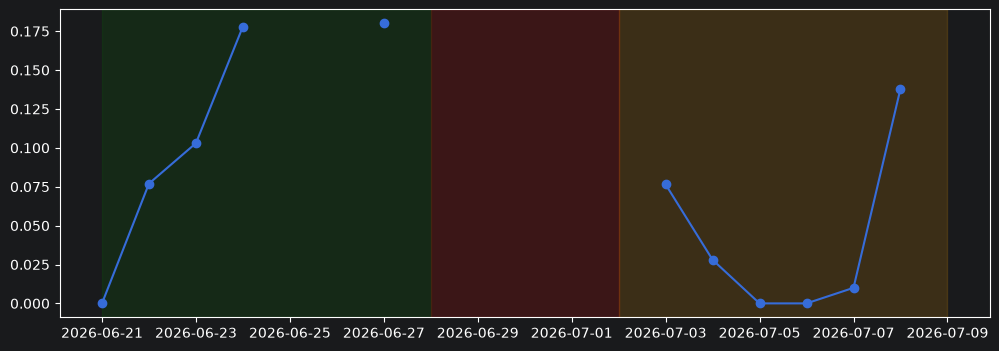

In [281]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    magnet_window.index,
    magnet_window.values,
    marker="o",
    label="Суточный расход",
)

ax.axvspan(
    before_start,
    magnet_example["start_date"],
    color="green",
    alpha=0.15,
    label="Окно до",
)

ax.axvspan(
    magnet_example["start_date"],
    magnet_example["end_date"] + pd.Timedelta(days=1),
    color="red",
    alpha=0.15,
    label="Дни магнитного эпизода",
)

ax.axvspan(
    magnet_example["end_date"] + pd.Timedelta(days=1),
    after_end + pd.Timedelta(days=1),
    color="orange",
    alpha=0.15,
    label="Окно после",
)

## 14. Контрольные периоды без событий

Для тех же приборов ищутся близкие по времени периоды без зарегистрированных событий, с одинаковой длительностью промежутка между окнами. Контроль выбирается по доступности данных, а не по результату потребления. Сравнение описательное: оно не устраняет все различия условий.

**Кандидаты для контроля.** Эпизод сдвигается на фиксированные расстояния ±14, ±28, ±42 и ±60 дней. Начало и конец сдвигаются одинаково, сохраняя промежуток между окнами. Отбор не использует результат расхода.

In [282]:
CONTROL_OFFSETS = [-14, 14, -28, 28, -42, 42, -60, 60]

control_parts = []

for offset in CONTROL_OFFSETS:
    candidate = magnet_comparison[
        ["anon_id", "episode_id", "start_date", "end_date"]
    ].copy()

    candidate["control_start"] = (
        candidate["start_date"] + pd.Timedelta(days=offset)
    )

    candidate["control_end"] = (
        candidate["end_date"] + pd.Timedelta(days=offset)
    )

    candidate["offset_days"] = offset

    control_parts.append(candidate)

control_candidates = pd.concat(
    control_parts,
    ignore_index=True,
)

control_candidates["control_id"] = control_candidates.index

**Проверка контрольных дат.** Показываются предложенные интервалы. Это ещё не принятые контроли: они могут содержать события, выйти за период наблюдений или пересечься.

In [283]:
display(
    control_candidates[
        [
            "anon_id",
            "episode_id",
            "offset_days",
            "control_start",
            "control_end",
        ]
    ].head(10)
)

,anon_id,episode_id,offset_days,control_start,control_end
0,1156864,66,-14,2026-07-01,2026-07-01
1,1159791,78,-14,2026-08-20,2026-08-20
2,1249509,90,-14,2026-09-09,2026-09-09
3,1439721,135,-14,2026-07-31,2026-07-31
4,1581018,179,-14,2026-06-21,2026-06-21
5,1581018,180,-14,2026-08-05,2026-08-05
6,1581018,181,-14,2026-08-15,2026-08-19
7,1591483,184,-14,2026-02-27,2026-02-27
8,1707796,211,-14,2026-08-16,2026-08-16
9,2131184,396,-14,2026-08-21,2026-08-21


**Даты любых событий.** Для каждого прибора собирается набор дат магнита, сброса и Холла. Он используется для проверки всего контрольного промежутка.

In [284]:
events_by_meter = (
    events_daily
    .groupby("anon_id")["data"]
    .apply(set)
    .to_dict()
)

**Контроли без событий.** Отсутствие событий требуется от начала окна до конца окна после, включая промежуток между ними. Это отсутствие записей в предоставленной таблице, не доказательство отсутствия любых воздействий.

In [285]:
event_free_flags = []

for candidate in control_candidates.itertuples():
    checked_dates = pd.date_range(
        candidate.control_start - pd.Timedelta(days=WINDOW_DAYS),
        candidate.control_end + pd.Timedelta(days=WINDOW_DAYS),
    )

    meter_event_dates = events_by_meter.get(candidate.anon_id, set())

    has_events = bool(set(checked_dates) & meter_event_dates)
    event_free_flags.append(not has_events)

control_candidates["event_free"] = event_free_flags

event_free_controls = control_candidates[
    control_candidates["event_free"]
].copy()

print("Кандидатов без событий:", len(event_free_controls))

Кандидатов без событий: 570


**Контрольные окна.** Для каждого кандидата создаются те же семь дней до и после. Правило одинаково для магнитных и контрольных сравнений.

In [286]:
control_window_parts = []

for offset in range(1, WINDOW_DAYS + 1):
    before = event_free_controls[
        ["control_id", "anon_id", "control_start"]
    ].copy()

    before["data"] = (
        before["control_start"] - pd.Timedelta(days=offset)
    )
    before["period"] = "До"

    after = event_free_controls[
        ["control_id", "anon_id", "control_end"]
    ].copy()

    after["data"] = (
        after["control_end"] + pd.Timedelta(days=offset)
    )
    after["period"] = "После"

    control_window_parts.extend([before, after])

control_windows = pd.concat(
    control_window_parts,
    ignore_index=True,
)

**Потребление в контроле.** Применяется тот же подготовленный расход и та же медиана, что для магнита. Это сохраняет сопоставимость расчётов.

In [287]:
control_windows = control_windows.merge(
    event_consumption[
        ["anon_id", "data", "comparison_consumption"]
    ],
    on=["anon_id", "data"],
    how="left",
    validate="many_to_one",
)

control_window_stats = (
    control_windows
    .groupby(["control_id", "period"])
    .agg(
        median_consumption=("comparison_consumption", "median"),
        available_days=("comparison_consumption", "count"),
    )
    .reset_index()
)

**Контроль до и после рядом.** Показатели окон соединяются по уникальному контрольному ID. Сам ID служит связи строк и не имеет физического смысла.

In [288]:
control_before = control_window_stats[
    control_window_stats["period"].eq("До")
].rename(columns={
    "median_consumption": "median_before",
    "available_days": "days_before",
}).drop(columns="period")

control_after = control_window_stats[
    control_window_stats["period"].eq("После")
].rename(columns={
    "median_consumption": "median_after",
    "available_days": "days_after",
}).drop(columns="period")

control_comparison = control_before.merge(
    control_after,
    on="control_id",
    validate="one_to_one",
)

**Пригодность контрольных данных.** В обоих окнах требуется минимум пять расходов. Кандидаты с недостаточными наблюдениями не участвуют в дальнейшем сравнении.

In [289]:
control_comparison = control_comparison[
    control_comparison["days_before"].ge(MIN_WINDOW_OBSERVATIONS)
    & control_comparison["days_after"].ge(MIN_WINDOW_OBSERVATIONS)
].copy()

eligible_controls = event_free_controls.merge(
    control_comparison,
    on="control_id",
    how="inner",
    validate="one_to_one",
)

**Непересекающиеся контроли.** Оставляется до трёх контролей на эпизод; одни календарные даты прибора не используются повторно в разных контролях. Выбор зависит от заданного порядка кандидатов, но не от наличия падения.

In [290]:
selected_control_ids = []
used_dates_by_meter = {}

for _, candidates in eligible_controls.groupby(
    ["anon_id", "episode_id"],
    sort=True,
):
    selected_count = 0

    for candidate in candidates.sort_values("control_id").itertuples():
        dates = set(pd.date_range(
            candidate.control_start - pd.Timedelta(days=WINDOW_DAYS),
            candidate.control_end + pd.Timedelta(days=WINDOW_DAYS),
        ))

        used_dates = used_dates_by_meter.setdefault(candidate.anon_id, set())

        if dates & used_dates:
            continue

        selected_control_ids.append(candidate.control_id)
        used_dates.update(dates)
        selected_count += 1

        if selected_count == 3:
            break

controls = eligible_controls[
    eligible_controls["control_id"].isin(selected_control_ids)
].copy()

print("Выбранных контролей:", len(controls))

Выбранных контролей: 165


**Одинаковый критерий падения.** На контроль применяется точно тот же критерий уровня и снижения. Иначе разница частот могла бы объясняться разными правилами.

In [291]:
controls["consumption_drop"] = (
    controls["median_before"].ge(MIN_EVENT_CHANGE)
    & controls["median_after"].le(
        controls["median_before"] * MAX_AFTER_FRACTION
    )
    & (
        controls["median_before"]
        - controls["median_after"]
    ).ge(MIN_EVENT_CHANGE)
)

print(
    "Падений в контрольных сравнениях:",
    controls["consumption_drop"].sum(),
)

Падений в контрольных сравнениях: 15


**Магнитные эпизоды с контролем.** В сравнении остаются только эпизоды, для которых выбран хотя бы один контроль. Два из трёх найденных падений после магнита не имеют пригодного контроля.

In [292]:
episodes_with_control = controls[
    ["anon_id", "episode_id"]
].drop_duplicates()

paired_magnet = magnet_comparison.merge(
    episodes_with_control,
    on=["anon_id", "episode_id"],
    how="inner",
    validate="one_to_one",
)

print("Магнитных эпизодов с контролем:", len(paired_magnet))
print("Приборов:", paired_magnet["anon_id"].nunique())
print("Падений:", paired_magnet["consumption_drop"].sum())

Магнитных эпизодов с контролем: 81
Приборов: 71
Падений: 1


**Равный вес эпизодов.** Сначала усредняется признак падения среди контролей одного эпизода, затем среди эпизодов. Поэтому эпизод с тремя контролями не получает втрое больший вес. Повторные эпизоды одного прибора всё ещё не независимы.

In [293]:
control_rate_by_episode = (
    controls
    .groupby(["anon_id", "episode_id"])["consumption_drop"]
    .mean()
    .rename("control_drop_rate")
    .reset_index()
)

paired_comparison = paired_magnet.merge(
    control_rate_by_episode,
    on=["anon_id", "episode_id"],
    validate="one_to_one",
)

drop_rates = pd.DataFrame({
    "Условия": ["После магнита", "Без событий"],
    "Доля падений, %": [
        paired_comparison["consumption_drop"].mean() * 100,
        paired_comparison["control_drop_rate"].mean() * 100,
    ],
})

display(drop_rates.round(2))

,Условия,"Доля падений, %"
0,После магнита,1.23
1,Без событий,9.26


**Результат контрольного сравнения.** Выбрано 165 контролей для 81 магнитного эпизода у 71 прибора. В сопоставимой магнитной выборке одно падение, в контролях — 15. При равном весе эпизодов доля падений составляет 1,23% после магнита и 9,26% без событий. Последняя величина отличается от простого 15/165: сначала усредняются контроли каждого эпизода. Повышенная частота после магнита здесь не обнаружена. Вывод относится к отобранным эпизодам; повторные эпизоды прибора зависимы, причинность и отсутствие любого влияния не доказаны.

## 15. Отрицательные разницы и экстремумы рядом с магнитом

Отдельно проверяются признаки, исключённые из анализа фонового расхода. Окно сопоставления — день события и соседние дни. Для многодневного интервала дата второго показания не является точной датой уменьшения.

**Окно близости к магниту.** Проверяются день магнита и соседние даты. Исходная дата события сохраняется, чтобы различать событие до, в день или после аномалии.

In [294]:
near_magnet_parts = []

for offset in [-1, 0, 1]:
    shifted_events = magnet_events[
        ["anon_id", "data"]
    ].rename(columns={"data": "magnet_date"})

    shifted_events["data"] = (
        shifted_events["magnet_date"]
        + pd.Timedelta(days=offset)
    )

    near_magnet_parts.append(shifted_events)

near_magnet_dates = pd.concat(
    near_magnet_parts,
    ignore_index=True,
)

**Совпадения отрицательных интервалов.** Одно падение может совпасть с несколькими магнитными днями. Для количества аномалий остаётся одна строка на прибор и дату, подробные связи сохраняются отдельно.

In [295]:
negative_magnet_matches = negative_intervals.merge(
    near_magnet_dates,
    on=["anon_id", "data"],
    how="inner",
    validate="one_to_many",
)

negative_near_magnet = (
    negative_magnet_matches
    .drop_duplicates(subset=["anon_id", "data"])
)

print("Отрицательных интервалов рядом с магнитом:",
      len(negative_near_magnet))

print("Приборов:",
      negative_near_magnet["anon_id"].nunique())

Отрицательных интервалов рядом с магнитом: 2
Приборов: 2


**Порядок событий.** Разница дат показывает, предшествовал ли магнит записи падения. Через пропуск дата второго показания не устанавливает момент уменьшения счётчика.

In [296]:
negative_magnet_matches["days_from_magnet"] = (
    negative_magnet_matches["data"]
    - negative_magnet_matches["magnet_date"]
).dt.days

display(
    negative_magnet_matches[
        [
            "anon_id",
            "previous_date",
            "data",
            "days_between",
            "interval_consumption",
            "magnet_date",
            "days_from_magnet",
        ]
    ]
)

,anon_id,previous_date,data,days_between,interval_consumption,magnet_date,days_from_magnet
0,1791315,2026-06-17,2026-09-18,93.0,-0.005,2026-09-17,1
1,6177761,2026-09-27,2026-09-29,2.0,-0.011,2026-09-30,-1
2,6177761,2026-09-27,2026-09-29,2.0,-0.011,2026-09-29,0


**Только отрицательные сутки.** Отдельно учитываются падения между соседними днями. Так многодневные интервалы не выдаются за суточные совпадения.

In [297]:
negative_daily_near_magnet = negative_near_magnet[
    negative_near_magnet["days_between"].eq(1)
]

print(
    "Отрицательных суточных разниц рядом с магнитом:",
    len(negative_daily_near_magnet),
)

Отрицательных суточных разниц рядом с магнитом: 0


**Экстремумы рядом с магнитом.** Ищутся расходы >10 м³ в окне ±1 день. Ноль совпадений относится только к этому окну, порогу и доступным расходам.

In [298]:
extreme_magnet_matches = extreme_days.merge(
    near_magnet_dates,
    on=["anon_id", "data"],
    how="inner",
    validate="one_to_many",
)

extreme_near_magnet = (
    extreme_magnet_matches
    .drop_duplicates(subset=["anon_id", "data"])
)

print("Экстремальных дней рядом с магнитом:",
      len(extreme_near_magnet))

print("Приборов:",
      extreme_near_magnet["anon_id"].nunique())

Экстремальных дней рядом с магнитом: 0
Приборов: 0


**Близость к магниту.** В окне ±1 день найдено два отрицательных многодневных интервала, но ни одной отрицательной суточной разницы и ни одного расхода >10 м³. У `1791315` уменьшение 0,005 м³ относится к 93-дневному промежутку — момент неизвестен. У `6177761` уменьшение 0,011 м³ зарегистрировано до магнитного дня. Эти совпадения не подтверждают последовательность «магнит → падение».

## 16. Длинный ноль, затем большой расход

Ищется серия минимум из семи нулевых суток при пакетах, после которой на следующий календарный день расход превышает 1 м³. Возможны как возобновление использования воды, так и задержка обновления показаний. Расход назад по дням не перераспределяется.

**Нулевая серия перед скачком.** Выбираются серии ≥7 дней при пакетах и вычисляется следующий календарный день. Пропуск после серии не считается немедленным возобновлением расхода.

In [299]:
MIN_ZERO_DAYS_BEFORE_SPIKE = 7

zero_before_spike = zero_runs[
    zero_runs["days"].ge(MIN_ZERO_DAYS_BEFORE_SPIKE)
].copy()

zero_before_spike["next_date"] = (
    zero_before_spike["end_date"]
    + pd.Timedelta(days=1)
)

**Расход следующего дня.** К каждой серии добавляется только известный суточный расход на следующую дату. Пустое значение не заменяется нулём.

In [300]:
next_day_consumption = daily[
    ["anon_id", "data", "daily_consumption"]
].rename(columns={
    "data": "next_date",
    "daily_consumption": "next_consumption",
})

zero_before_spike = zero_before_spike.merge(
    next_day_consumption,
    on=["anon_id", "next_date"],
    how="left",
    validate="many_to_one",
)

**Ноль, затем >1 м³.** Критерий выделяет большой расход сразу после подтверждённой нулевой серии. Само совпадение не различает задержку показаний и реальное возобновление использования воды.

In [301]:
zero_then_spikes = zero_before_spike[
    zero_before_spike["next_consumption"].gt(ABSOLUTE_THRESHOLD)
].copy()

print("Найдено случаев:", len(zero_then_spikes))
print("Приборов:", zero_then_spikes["anon_id"].nunique())

display(
    zero_then_spikes[
        [
            "anon_id",
            "start_date",
            "end_date",
            "days",
            "next_date",
            "next_consumption",
        ]
    ]
)

Найдено случаев: 1
Приборов: 1


,anon_id,start_date,end_date,days,next_date,next_consumption
5932,8727125,2025-12-19,2026-02-19,63,2026-02-20,1.278


**История перехода.** Для просмотра берётся вся серия и три недели после скачка. Выбор первой строки предполагает наличие найденного случая; на других данных выборка может быть пустой.

In [302]:
zero_spike_example = zero_then_spikes.iloc[0]
zero_spike_id = zero_spike_example["anon_id"]

plot_start = (
    zero_spike_example["start_date"] - pd.Timedelta(days=7)
)

plot_end = (
    zero_spike_example["next_date"] + pd.Timedelta(days=21)
)

zero_spike_history = readings_sorted[
    readings_sorted["anon_id"].eq(zero_spike_id)
    & readings_sorted["data"].between(plot_start, plot_end)
].copy()

**Строки около скачка.** Проверяются показания и пакеты за соседние даты. Особенно важно, сохраняется ли новое показание или затем происходит отрицательная разница.

In [303]:
spike_date = zero_spike_example["next_date"]

display(
    zero_spike_history[
        zero_spike_history["data"].between(
            spike_date - pd.Timedelta(days=3),
            spike_date + pd.Timedelta(days=3),
        )
    ][
        [
            "data",
            "pokazanie",
            "daily_consumption",
            "paketov_za_sutki",
        ]
    ]
)

,data,pokazanie,daily_consumption,paketov_za_sutki
583196,2026-02-17,390.153,0.000,1
583197,2026-02-18,390.153,0.000,1
583198,2026-02-19,390.153,0.000,1
583199,2026-02-20,391.431,1.278,1
583200,2026-02-21,391.436,0.005,1
583201,2026-02-22,391.436,0.000,1
583202,2026-02-23,421.004,29.568,1


**Накопительное показание после нуля.** Горизонтальный участок и последующее изменение видны напрямую. Красная линия отмечает дату большого расхода.

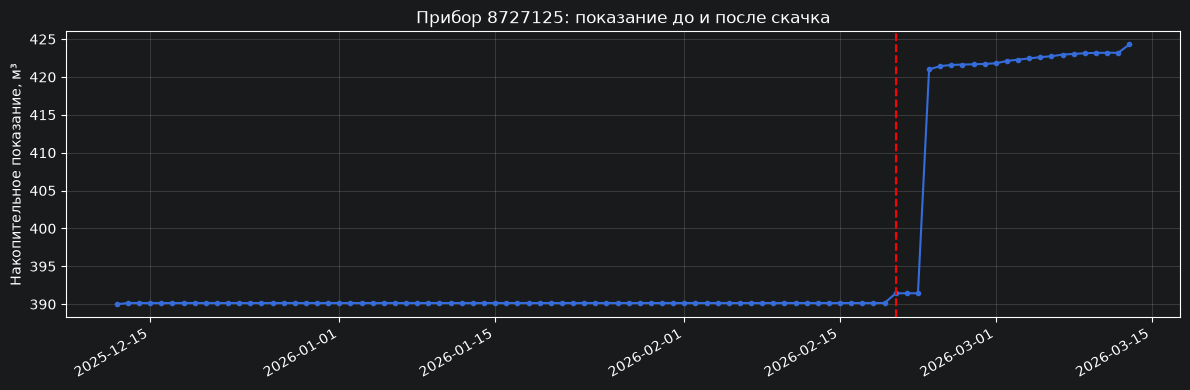

In [304]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    zero_spike_history["data"],
    zero_spike_history["pokazanie"],
    marker=".",
)

ax.axvline(spike_date, color="red", linestyle="--")

ax.set_title(f"Прибор {zero_spike_id}: показание до и после скачка")
ax.set_ylabel("Накопительное показание, м³")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Режим после скачка.** График показывает, остаётся ли пик одиночным или начинается регулярное потребление. Значение скачка не распределяется по предшествующим нулевым дням без подтверждения задержки.

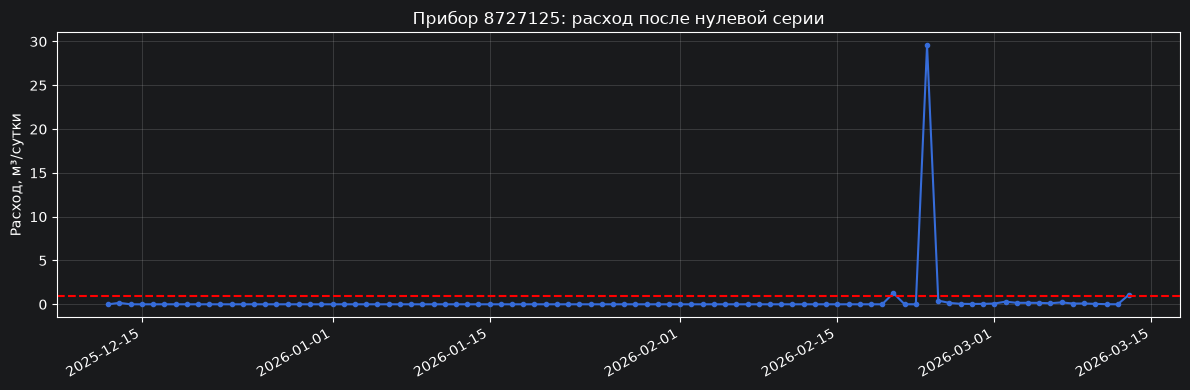

In [305]:
zero_spike_series = get_consumption_series(zero_spike_id)
zero_spike_window = zero_spike_series.loc[plot_start:plot_end]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    zero_spike_window.index,
    zero_spike_window.values,
    marker=".",
)

ax.axhline(ABSOLUTE_THRESHOLD, color="red", linestyle="--")
ax.set_title(f"Прибор {zero_spike_id}: расход после нулевой серии")
ax.set_ylabel("Расход, м³/сутки")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Дополнительная находка.** У `8727125` после 63 нулевых суток при пакетах (19.12.2025–19.02.2026) на следующий день зарегистрировано 1,278 м³. Найден один случай. Данные совместимы с разными объяснениями; распределять скачок по предыдущим дням без доказательства задержки нельзя.

## 17. Повторяющаяся величина падений счётчика

Проверяется гипотеза о крупных уменьшениях, близких к кратным 327,68 м³. Гипотеза возникла после просмотра данных; допуск выбирается исследователем. Это направление поиска механизма ошибок, а не подтверждённая техническая причина.

**Размер крупных падений.** Отбираются уменьшения ≥100 м³ по модулю, включая многодневные интервалы. Здесь изучается счётчик, а не только суточный расход.

In [306]:
large_drops = negative_intervals[
    negative_intervals["interval_consumption"].abs().ge(100)
].copy()

large_drops["drop_size"] = (
    large_drops["interval_consumption"].abs()
)

print("Крупных уменьшений:", len(large_drops))
print("Приборов:", large_drops["anon_id"].nunique())

Крупных уменьшений: 156
Приборов: 59


**Повторяющиеся величины.** Округление до целого м³ используется только для обзора частот. Скопления похожих размеров формируют гипотезу общего шага; исходные значения не округляются.

In [307]:
rounded_drop_counts = (
    large_drops["drop_size"]
    .round(0)
    .value_counts()
)

display(
    rounded_drop_counts.head(10).rename("Количество случаев")
)

drop_size
328.0        47
655.0        29
983.0        27
656.0        13
1311.0        7
327.0         7
295.0         6
4273492.0     2
778.0         1
787.0         1
Name: Количество случаев, dtype: int64

**Гипотеза шага 327,68 м³.** Для каждого уменьшения выбирается ближайшее кратное и вычисляется отклонение. Значение шага выбрано после просмотра данных, поэтому совпадения не являются независимым подтверждением механизма.

In [308]:
SUSPECTED_STEP = 327.68

large_drops["step_multiple"] = (
    large_drops["drop_size"] / SUSPECTED_STEP
).round().astype(int)

large_drops["expected_drop"] = (
    large_drops["step_multiple"] * SUSPECTED_STEP
)

large_drops["difference_from_step"] = (
    large_drops["drop_size"] - large_drops["expected_drop"]
)

Отклонение от положительного кратного должно быть ≤0,1 м³. Это исследовательский допуск, не паспортная погрешность прибора.

In [309]:
STEP_TOLERANCE = 0.1

step_like_drops = large_drops[
    large_drops["step_multiple"].ge(1)
    & large_drops["difference_from_step"].abs().le(STEP_TOLERANCE)
].copy()

print("Совпадений:", len(step_like_drops))
print("Приборов:", step_like_drops["anon_id"].nunique())

Совпадений: 73
Приборов: 35


**Примеры совпадений.** Показываются величина, кратность и остаток. Длина интервала помогает отличить суточное падение от уменьшения через разрыв наблюдений.

In [310]:
display(
    step_like_drops.sort_values("drop_size")[
        [
            "anon_id",
            "data",
            "days_between",
            "drop_size",
            "step_multiple",
            "difference_from_step",
        ]
    ].head(15)
)

,anon_id,data,days_between,drop_size,step_multiple,difference_from_step
135667,5905051,2025-12-07,3.0,327.620000,1,-6.000000e-02
135675,5905051,2026-09-04,1.0,327.634471,1,-4.552941e-02
390375,3418502,2026-08-28,1.0,327.636000,1,-4.400000e-02
448804,2569627,2026-01-19,1.0,327.637000,1,-4.300000e-02
151342,7233648,2026-02-19,2.0,327.643000,1,-3.700000e-02
268465,8498147,2026-09-18,1.0,327.655778,1,-2.422222e-02
384866,8305637,2026-08-07,1.0,327.667446,1,-1.255385e-02
456281,6316651,2026-01-25,1.0,327.672000,1,-8.000000e-03
156652,8953379,2026-09-30,1.0,327.675000,1,-5.000000e-03
156638,8953379,2026-09-16,1.0,327.675000,1,-5.000000e-03


Сравнение 0,05, 0,1 и 0,5 м³ показывает зависимость количества совпадений от границы. Устойчивость части случаев полезна, но не устанавливает техническую причину.

In [311]:
tolerance_results = []

for tolerance in [0.05, 0.1, 0.5]:
    selected = large_drops[
        large_drops["step_multiple"].ge(1)
        & large_drops["difference_from_step"].abs().le(tolerance)
    ]

    tolerance_results.append({
        "Допуск, м³": tolerance,
        "Случаев": len(selected),
        "Приборов": selected["anon_id"].nunique(),
    })

display(pd.DataFrame(tolerance_results))

,"Допуск, м³",Случаев,Приборов
0,0.05,47,24
1,0.10,73,35
2,0.50,129,51


In [312]:
step_like_drops_info = step_like_drops.merge(
    meters[["anon_id", "tip", "bs"]],
    on="anon_id",
    how="left",
    validate="many_to_one",
)

display(
    step_like_drops_info.groupby("tip").agg(
        cases=("anon_id", "size"),
        meters=("anon_id", "nunique"),
    )
)

,cases,meters
tip,,
AQUA2,73,35


Показан диапазон 100–1 500 м³; красные линии — первые четыре кратных гипотезы. Более крупные падения скрыты только для отображения. Прибавлять шаг для автоматического исправления данных оснований нет.

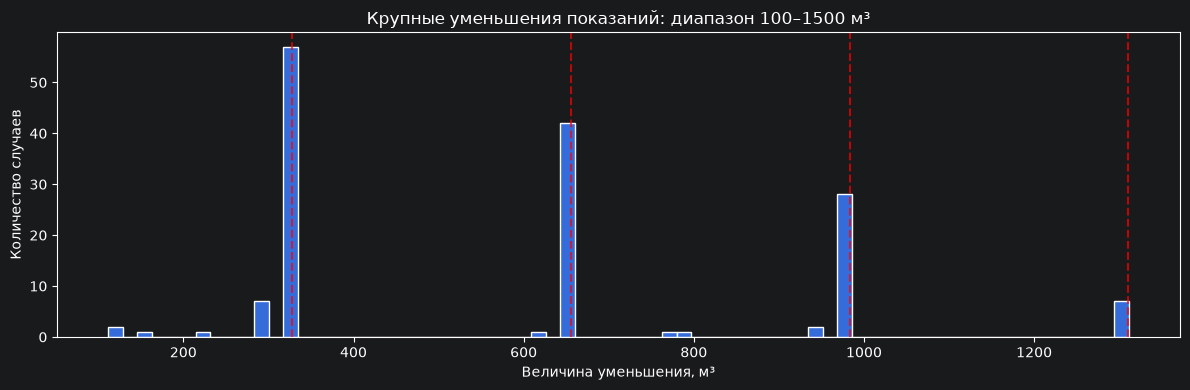

In [313]:
drops_for_plot = large_drops[
    large_drops["drop_size"].le(1500)
]

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(drops_for_plot["drop_size"], bins=70, edgecolor="white")

for multiple in [1, 2, 3, 4]:
    ax.axvline(
        SUSPECTED_STEP * multiple,
        color="red",
        linestyle="--",
        alpha=0.7,
    )

ax.set_title("Крупные уменьшения показаний: диапазон 100–1500 м³")
ax.set_xlabel("Величина уменьшения, м³")
ax.set_ylabel("Количество случаев")

plt.tight_layout()
plt.show()

**Техническая гипотеза.** Среди 156 крупных уменьшений у 59 приборов найдено 73 близких к кратным 327,68 м³ случая у 35 приборов при допуске 0,1 м³. Все эти приборы относятся к `AQUA2`. При допуске 0,05 м³ остаются 47 случаев у 24 приборов, при 0,5 м³ — 129 у 51. Закономерность полезна для проверки формата и обработки счётчика, но гипотеза и допуск выбраны на тех же данных. Для подтверждения нужны исходные пакеты и проверка на отдельном периоде.

## 18. Результаты и очередь проверки

Сводка объединяет критерии, количества и примеры. Очередь отражает конкретные основания для проверки, а не вероятность неисправности. Прибор получает наивысший из предусмотренных приоритетов; категории результатов пересекаются.

Функция считает уникальные приборы и сохраняет первые три ID переданной выборки. Перед повторным заполнением список должен быть очищен этой ячейкой.

In [314]:
summary_rows = []

def add_result(name, criterion, ids):
    unique_ids = pd.Series(
        list(ids),
        dtype="string",
    ).drop_duplicates()

    summary_rows.append({
        "Проверка": name,
        "Критерий": criterion,
        "Приборов": len(unique_ids),
        "Примеры anon_id": ", ".join(unique_ids.head(3)),
    })

In [315]:
add_result(
    "Уменьшение показания",
    "Отрицательная разница между наблюдениями",
    negative_intervals.sort_values("interval_consumption")["anon_id"],
)

add_result(
    "Отрицательный суточный расход",
    "Отрицательная разница за соседние дни",
    negative_daily.sort_values("daily_consumption")["anon_id"],
)

add_result(
    "Абсолютный всплеск",
    "Расход >1 м³/сутки",
    absolute_spikes.sort_values(
        "daily_consumption", ascending=False
    )["anon_id"],
)

add_result(
    "Относительный всплеск",
    ">5 медиан и ≥0,5 м³; фон ≥0,01 м³, минимум 30 дней",
    relative_spikes.sort_values(
        "times_above_usual", ascending=False
    )["anon_id"],
)

In [316]:
add_result(
    "Экстремальный расход",
    ">10 м³/сутки; физический предел не установлен",
    extreme_days.sort_values(
        "daily_consumption", ascending=False
    )["anon_id"],
)

add_result(
    "Кандидат на проверку утечки",
    "≥30 последовательных положительных суток",
    leak_candidates.sort_values("days", ascending=False)["anon_id"],
)

add_result(
    "Длительный ноль при пакетах",
    "≥14 последовательных нулевых суток, пакеты каждый день",
    zero_candidates.sort_values("days", ascending=False)["anon_id"],
)

add_result(
    "Устойчивое изменение уровня",
    "Различие медиан четвертей: ≥3× опорного уровня и ≥0,1 м³",
    step_candidates.index,
)

add_result(
    "Падение после магнита",
    "После ≤50% уровня до; снижение ≥0,02 м³",
    magnet_drops.sort_values(
        "median_before", ascending=False
    )["anon_id"],
)

In [317]:
add_result(
    "Большой скачок с последующим падением",
    ">100 м³, затем падение ≥80% скачка в течение трёх дней",
    spike_drop_pairs.sort_values(
        "peak_consumption", ascending=False
    )["anon_id"],
)

add_result(
    "Концентрация экстремумов у AQUA2",
    "Все приборы с расходом >100 м³ относятся к AQUA2",
    very_extreme_days.sort_values(
        "daily_consumption", ascending=False
    )["anon_id"],
)

add_result(
    "Ноль, затем всплеск",
    "≥7 нулевых суток при пакетах, затем на следующий день >1 м³",
    zero_then_spikes["anon_id"],
)

results_summary = pd.DataFrame(summary_rows)
display(results_summary)

,Проверка,Критерий,Приборов,Примеры anon_id
0,Уменьшение показания,Отрицательная разница между наблюдениями,102,"2519659, 2491162, 8908023"
1,Отрицательный суточный расход,Отрицательная разница за соседние дни,79,"2491162, 8908023, 2159987"
2,Абсолютный всплеск,Расход >1 м³/сутки,368,"2491162, 8908023, 2159987"
3,Относительный всплеск,">5 медиан и ≥0,5 м³; фон ≥0,01 м³, минимум 30 ...",334,"8908023, 2491162, 8973572"
4,Экстремальный расход,>10 м³/сутки; физический предел не установлен,63,"2491162, 8908023, 2159987"
5,Кандидат на проверку утечки,≥30 последовательных положительных суток,1168,"1968874, 2931056, 7496751"
6,Длительный ноль при пакетах,"≥14 последовательных нулевых суток, пакеты каж...",1099,"9686922, 7558835, 9354769"
7,Устойчивое изменение уровня,Различие медиан четвертей: ≥3× опорного уровня...,14,"1581018, 2194061, 2567791"
8,Падение после магнита,"После ≤50% уровня до; снижение ≥0,02 м³",3,"6471186, 5529203, 4183513"
9,Большой скачок с последующим падением,">100 м³, затем падение ≥80% скачка в течение т...",37,"2491162, 8908023, 2159987"


Первая группа - >1 000 м³.
Вторая — пары скачков и падений или характерный шаг.
Третья - ступенька или нули ≥90 дней. Приборы предыдущих групп исключаются из следующих.

In [318]:
priority_1_ids = set(
    daily.loc[
        daily["daily_consumption"].gt(1000),
        "anon_id",
    ]
)

priority_2_ids = (
    set(spike_drop_pairs["anon_id"])
    | set(step_like_drops["anon_id"])
) - priority_1_ids

long_zero_ids = set(
    zero_runs.loc[zero_runs["days"].ge(90), "anon_id"]
)

priority_3_ids = (
    set(step_candidates.index)
    | long_zero_ids
) - priority_1_ids - priority_2_ids

Для каждого прибора сохраняются приоритет и понятное основание проверки. Это операционная очередь, а не статистическая оценка риска.

In [319]:
checklist_parts = []

groups = [
    (priority_1_ids, 1, "Суточный расход >1000 м³"),
    (priority_2_ids, 2, "Скачки с падениями или характерный шаг счётчика"),
    (priority_3_ids, 3, "Изменение уровня или нулевой расход ≥90 дней"),
]

for ids, priority, reason in groups:
    part = pd.DataFrame({"anon_id": sorted(ids)})
    part["priority"] = priority
    part["reason"] = reason
    checklist_parts.append(part)

inspection_queue = pd.concat(
    checklist_parts,
    ignore_index=True,
)

Добавляются станция, тип и максимальный суточный расход. Внутри приоритета выше стоят большие максимумы. Список показывает техническую проверку данных прежде, чем делать выводы о потребителе.

In [320]:
maximum_by_meter = (
    daily.groupby("anon_id")["daily_consumption"]
    .max()
    .rename("maximum_daily_consumption")
    .reset_index()
)

inspection_queue = inspection_queue.merge(
    meters[["anon_id", "bs", "tip"]],
    on="anon_id",
    validate="one_to_one",
)

inspection_queue = inspection_queue.merge(
    maximum_by_meter,
    on="anon_id",
    validate="one_to_one",
)

inspection_queue = inspection_queue.sort_values(
    ["priority", "maximum_daily_consumption"],
    ascending=[True, False],
)

display(inspection_queue.head(20))

,anon_id,priority,reason,bs,tip,maximum_daily_consumption
1,2491162,1,Суточный расход >1000 м³,BS-07,AQUA2,3.005504e+06
3,8908023,1,Суточный расход >1000 м³,BS-07,AQUA2,2.684039e+06
0,2159987,1,Суточный расход >1000 м³,BS-07,AQUA2,2.834770e+03
2,7891133,1,Суточный расход >1000 м³,BS-05,AQUA2,2.124960e+03
24,5359103,2,Скачки с падениями или характерный шаг счётчика,BS-07,AQUA2,5.303171e+02
10,2030325,2,Скачки с падениями или характерный шаг счётчика,BS-03,AQUA2,4.259160e+02
21,4964924,2,Скачки с падениями или характерный шаг счётчика,BS-07,AQUA2,4.010470e+02
40,8498147,2,Скачки с падениями или характерный шаг счётчика,BS-05,AQUA2,3.639711e+02
6,1423304,2,Скачки с падениями или характерный шаг счётчика,BS-07,AQUA2,3.432248e+02
37,8190741,2,Скачки с падениями или характерный шаг счётчика,BS-03,AQUA2,3.279960e+02


## Итог работы

Количество ниже означает уникальные приборы с заданным признаком. Категории пересекаются и не складываются в общее число неисправностей.

| Проверка | Основное правило | Приборов |
|---|---|---:|
| Уменьшение показания | Отрицательная разница между любыми наблюдениями | 102 |
| Отрицательные сутки | То же при интервале ровно сутки | 79 |
| Абсолютные всплески | >1 м³/сутки | 368 |
| Относительные всплески | >5 индивидуальных медиан и ≥0,5 м³ при достаточном фоне | 334 |
| Экстремальные расходы | >10 м³/сутки | 63 |
| Возможная утечка | ≥30 последовательных положительных суток | 1 168 |
| Ноль при пакетах | ≥14 последовательных суток | 1 099 |
| Изменение уровня | Устойчивое различие четвертей ≥3× опорного уровня и ≥0,1 м³ | 14 |
| Падение после магнита | Уровень после ≤50% уровня до, снижение ≥0,02 м³ | 3 |

В строке изменения уровня дополнительно требуются ≥30 расходов и ≥70% покрытия каждой половины, ≥10 расходов каждой четверти. При фоновых уровнях ниже 0,01 м³ применяется техническая нижняя опорная граница, поэтому рост от нуля не называется фактическим трёхкратным ростом.

Дополнительные наблюдения: пары скачков и падений у 37 приборов; концентрация >100 м³ у 55 приборов типа `AQUA2`; длинный ноль перед скачком у `8727125`. Повторяющиеся размеры уменьшений уточняют гипотезу общего механизма ошибок у этого типа, но не устанавливают механизм.

### Примеры приоритета по моим выводам

| Приоритет | Основание | Действие |
|---|---|---|
| 1 | Суточная разница >1 000 м³ | Проверить исходные показания, пакеты и историю сбросов/замен |
| 2 | Скачки с последующими падениями или характерный повторяющийся шаг | Проверить измерение, представление счётчика и обработку данных |
| 3 | Устойчивое изменение уровня или нулевые серии ≥90 дней | Уточнить использование объекта и состояние прибора |

Первая очередь: **`2491162`, `8908023`, `2159987`, `7891133`**. Их крупные положительные скачки сопровождаются падениями, поэтому достоверность показаний следует установить до выводов о фактическом использовании воды.

Очередь в коде является выборочной: она не включает автоматически все широкие флаги, например любую 30-дневную положительную серию или единичный расход >1 м³. Такие признаки требуют контекста и дальнейшего наблюдения.
